# Cross-Dataset Evaluation of Machine-Learning Autism Risk Screening with Fairness Analysis for a Lesotho Context


**Pipeline sections:**
1. Imports & setup
2. Data loading & preprocessing
3. Exploratory data analysis
4. Model training (behavioural, demographic)
5. Late fusion & feature-level fusion evaluation
6. Cross-dataset robustness check (in-distribution CV vs external Polish test set)
7. DHS threshold recalibration
8. Ablation study
9. Behavioural ensemble & deployment model
10. Clinical metrics, calibration, benchmark comparison on the cross-dataset test set
11. Comorbidity adjustment
12. Subgroup and geographic fairness evaluation
13. Final combined deployment model

# Install dependencies

In [27]:

 !pip install xgboost shap librosa imbalanced-learn pyreadstat openpyxl seaborn --quiet


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Library Imports

In [28]:
import os
import sys
import warnings
import traceback
from pathlib import Path

warnings.filterwarnings("ignore")

# Clear any previously loaded pandas modules.
for module_name in [name for name in list(sys.modules)
                    if name == "pandas" or name.startswith("pandas.")]:
    sys.modules.pop(module_name, None)

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

print(sys.executable)

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
    learning_curve,
    GridSearchCV,
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
)

from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

import sklearn
print(f"scikit-learn {sklearn.__version__}")

import xgboost as xgb

# Load SHAP if available. If not, continue without explainability.
try:
    import shap
    SHAP_AVAILABLE = True
except Exception as exc:
    shap = None
    SHAP_AVAILABLE = False
    SHAP_IMPORT_ERROR = traceback.format_exc()

    print(
        f"SHAP could not be loaded, so explainability analysis "
        f"will be skipped ({exc.__class__.__name__}: {exc})."
    )

import random
import joblib

# Set the random seed for reproducibility.
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Locate the project folder automatically.
WORKSPACE_ROOT = Path(r"C:/Users/PC/Autism-Risk-Screening")
PROJECT_ROOT = Path.cwd()

for candidate in [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    WORKSPACE_ROOT,
]:
    if (candidate / "data" / "raw" / "qchat" / "Autusim_DATA_Clean_Encoded.xlsx").exists():
        PROJECT_ROOT = candidate
        break

os.chdir(PROJECT_ROOT)

# Create output folders if they do not already exist.
os.makedirs("outputs/evaluation", exist_ok=True)
os.makedirs("outputs/fairness", exist_ok=True)
os.makedirs("outputs/alignment", exist_ok=True)
os.makedirs("models", exist_ok=True)

print(f"Imports completed successfully (XGBoost {xgb.__version__})")
print(f"Project root: {PROJECT_ROOT}")

c:\Users\PC\Autism-Risk-Screening\.venv\Scripts\python.exe
scikit-learn 1.5.1
Imports completed successfully (XGBoost 2.1.1)
Project root: c:\Users\PC\Autism-Risk-Screening


### Data Loading and Preprocessing

The model was trained using the unified Q-CHAT-10 toddler dataset developed by Abbadi and Thabtah (2025). To ensure consistency with the target age group, only children aged between 18 and 36 months (1.5–3.0 years) were included, resulting in a final training dataset of 1,601 records.

Model performance was evaluated using an independent Polish clinical dataset published by Niedźwiecka et al. (2020). The dataset is based on the Q-CHAT-25 questionnaire, but only items 1–10 were used so that the feature set matched the training data. The dataset was loaded from the `data/raw/qchat/QCHAT_dataset2_mendeley.sav` file using the `pyreadstat` library.


In [29]:

print("Working directory ):", os.getcwd())

Working directory ): c:\Users\PC\Autism-Risk-Screening


In [30]:
# Load Q-CHAT dataset
qchat_file = PROJECT_ROOT / "data" / "raw" / "qchat" / "Autusim_DATA_Clean_Encoded.xlsx"
if not qchat_file.exists():
    fallback_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path(r"C:/Users/PC/Autism-Risk-Screening")]
    for candidate in fallback_roots:
        candidate_file = candidate / "data" / "raw" / "qchat" / "Autusim_DATA_Clean_Encoded.xlsx"
        if candidate_file.exists():
            qchat_file = candidate_file
            break
    else:
        raise FileNotFoundError(
            "Could not find data/raw/qchat/Autusim_DATA_Clean_Encoded.xlsx. "
            "Check that the dataset is present in the project root.",
        )

df_raw = pd.read_excel(qchat_file)

# Keep only toddlers aged 18–36 months
df = df_raw[
    (df_raw["Age"] >= 1.5) &
    (df_raw["Age"] <= 3.0)
] .copy()

# Rename columns to match the training pipeline
df = df.rename(columns={
    "a1": "q1",
    "a2": "q2",
    "a3": "q3",
    "a4": "q4",
    "a5": "q5",
    "a6": "q6",
    "a7": "q7",
    "a8": "q8",
    "a9": "q9",
    "a10": "q10",
    "Age": "age_years",
    "Gender": "sex",
    "Class": "label"
})

# Remove any age values outside the target range
df = df[df["age_years"] <= 3.0]

print(f"Training dataset: {len(df)} rows")

print(
    f"Age range: "
    f"{df['age_years'].min():.2f}–{df['age_years'].max():.2f} years "
    f"({df['age_years'].min()*12:.0f}–{df['age_years'].max()*12:.0f} months)"
)

print(f"Class distribution: {df['label'].value_counts().to_dict()}")

print(
    f"Sex distribution: {df['sex'].value_counts().to_dict()} "
    f"(0 = Female, 1 = Male)"
)

df.head()

Training dataset: 1601 rows
Age range: 1.50–3.00 years (18–36 months)
Class distribution: {0: 929, 1: 672}
Sex distribution: {1: 1154, 0: 447} (0 = Female, 1 = Male)


,id,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,age_years,sex,Ethnicity,Jaundice,Family_ASD,label,Who_Completed,Qchat_Score
0,1,0,0,0,0,0,0,1,1,0,1,2.333333,0,0,0,0,0,family member,3
1,2,1,1,0,0,0,1,1,0,0,0,3.000000,1,1,0,0,1,family member,4
2,3,1,0,0,0,0,0,1,1,0,1,3.000000,1,0,0,0,1,family member,4
3,4,1,1,1,1,1,1,1,1,1,1,2.000000,1,2,1,0,1,family member,10
4,5,1,1,0,1,1,1,1,1,1,1,1.666667,0,1,1,1,1,family member,9


In [31]:
# Load the Polish Q-CHAT test dataset
from pathlib import Path
import pandas as pd

project_root = Path(globals().get("PROJECT_ROOT", Path.cwd()))
qchat_test_file = project_root / "data" / "raw" / "qchat" / "QCHAT_dataset2 mendeley.sav"
if not qchat_test_file.exists():
    fallback_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path(r"C:/Users/PC/Autism-Risk-Screening")]
    for candidate in fallback_roots:
        candidate_file = candidate / "data" / "raw" / "qchat" / "QCHAT_dataset2 mendeley.sav"
        if candidate_file.exists():
            qchat_test_file = candidate_file
            break
    else:
        raise FileNotFoundError(
            "Could not find data/raw/qchat/QCHAT_dataset2 mendeley.sav. "
            "Check that the dataset is present in the project root.",
        )

try:
    import pyreadstat

    df_test_raw, meta = pyreadstat.read_sav(qchat_test_file)

    # Convert Q-CHAT items 1-10 into binary responses
    # Q1-Q9: score >= 2 means atypical
    # Q10 is scored in the opposite direction

    for i in range(1, 11):
        raw = pd.to_numeric(
            df_test_raw[f"qchat{i}recode"],
            errors="coerce"
        )

        if i == 10:
            df_test_raw[f"q{i}"] = (raw <= 2).astype(float)
        else:
            df_test_raw[f"q{i}"] = (raw >= 2).astype(float)

    # Create ASD labels
    df_test_raw["label"] = (
        pd.to_numeric(df_test_raw["group"], errors="coerce") == 1
).astype(int)

    # Convert sex to binary (Male=1, Female=0)
    df_test_raw["sex"] = (
        pd.to_numeric(df_test_raw["sex"], errors="coerce") == 1
).astype(int)

    # Convert age from months to years
    df_test_raw["age_years"] = (
        pd.to_numeric(df_test_raw["age"], errors="coerce") / 12
)

    # These variables are not available in this dataset
    df_test_raw["Jaundice"] = 0
    df_test_raw["Family_ASD"] = 0

    # Keep children aged 18-36 months
    df_test = df_test_raw[
        (df_test_raw["age_years"] >= 1.5) &
        (df_test_raw["age_years"] <= 3.0)
] .copy()

    required_cols = (
        [f"q{i}" for i in range(1, 11)] +
        ["age_years", "sex", "label", "Jaundice", "Family_ASD"]
    )

    df_test = df_test.dropna(subset=required_cols)

    print(f"Polish test set: {len(df_test)} rows")
    print(
        f"Age range: {df_test['age_years'].min():.2f} - "
        f"{df_test['age_years'].max():.2f} years"
    )
    print(f"Class distribution: {df_test['label'].value_counts().to_dict()}")
    print(f"Sex distribution: {df_test['sex'].value_counts().to_dict()}")

    print(
        f"Q1 mean = {df_test['q1'].mean():.3f}, "
        f"Q10 mean = {df_test['q10'].mean():.3f}"
    )

    print(
        "Group labels:",
        meta.variable_value_labels.get("group", {})
    )

    group = pd.to_numeric(df_test_raw["group"], errors="coerce")

    print(
        f"ASD: {(group == 1).sum()}  "
        f"Control: {(group == 7).sum()}"
    )

    USE_POLISH_TEST = len(df_test) >= 20

except Exception as e:

    print(f"Could not load Polish test set: {e}")

    USE_POLISH_TEST = False
    df_test = None

Polish test set: 252 rows
Age range: 1.50 - 2.00 years
Class distribution: {1: 135, 0: 117}
Sex distribution: {1: 157, 0: 95}
Q1 mean = 0.313, Q10 mean = 0.794
Group labels: {1.0: 'ASD', 7.0: 'control'}
ASD: 135  Control: 117


In [32]:
# Features used in the model

QCHAT_COLS = [f"q{i}" for i in range(1, 11)]
DEM_COLS = ["age_years", "sex", "Jaundice", "Family_ASD"]


# Split the data

if USE_POLISH_TEST:

    # Use the full dataset for training
    X_beh_train = df[QCHAT_COLS].values.astype(float)
    X_dem_train = df[DEM_COLS].values.astype(float)
    y_train = df["label"].values.astype(int)

    # Use the Polish dataset for testing
    X_beh_test = df_test[QCHAT_COLS].values.astype(float)
    X_dem_test = df_test[DEM_COLS].values.astype(float)
    y_test = df_test["label"].values.astype(int)

    df_test_ref = df_test.reset_index(drop=True)

else:

    # Split the original dataset into training and testing sets
    X_beh_all = df[QCHAT_COLS].values.astype(float)
    X_dem_all = df[DEM_COLS].values.astype(float)
    y_all = df["label"].values.astype(int)

    idx = np.arange(len(df))

    idx_train, idx_test = train_test_split(
        idx,
        test_size=0.2,
        stratify=y_all,
        random_state=SEED
    )

    X_beh_train, X_beh_test, y_train, y_test = train_test_split(
        X_beh_all,
        y_all,
        test_size=0.2,
        stratify=y_all,
        random_state=SEED
    )

    X_dem_train = X_dem_all[idx_train]
    X_dem_test = X_dem_all[idx_test]

    df_test_ref = df.iloc[idx_test].reset_index(drop=True)


# Check the datasets

print(f"Train samples: {len(y_train)}")
print(f"Test samples: {len(y_test)}")

train_dist = dict(zip(*np.unique(y_train, return_counts=True)))
test_dist = dict(zip(*np.unique(y_test, return_counts=True)))

print(f"Train class distribution: {train_dist}")
print(f"Test class distribution: {test_dist}")

print(f"Demographic features: {DEM_COLS}")



Train samples: 1601
Test samples: 252
Train class distribution: {0: 929, 1: 672}
Test class distribution: {0: 117, 1: 135}
Demographic features: ['age_years', 'sex', 'Jaundice', 'Family_ASD']


---
# Exploratory Data Analysis




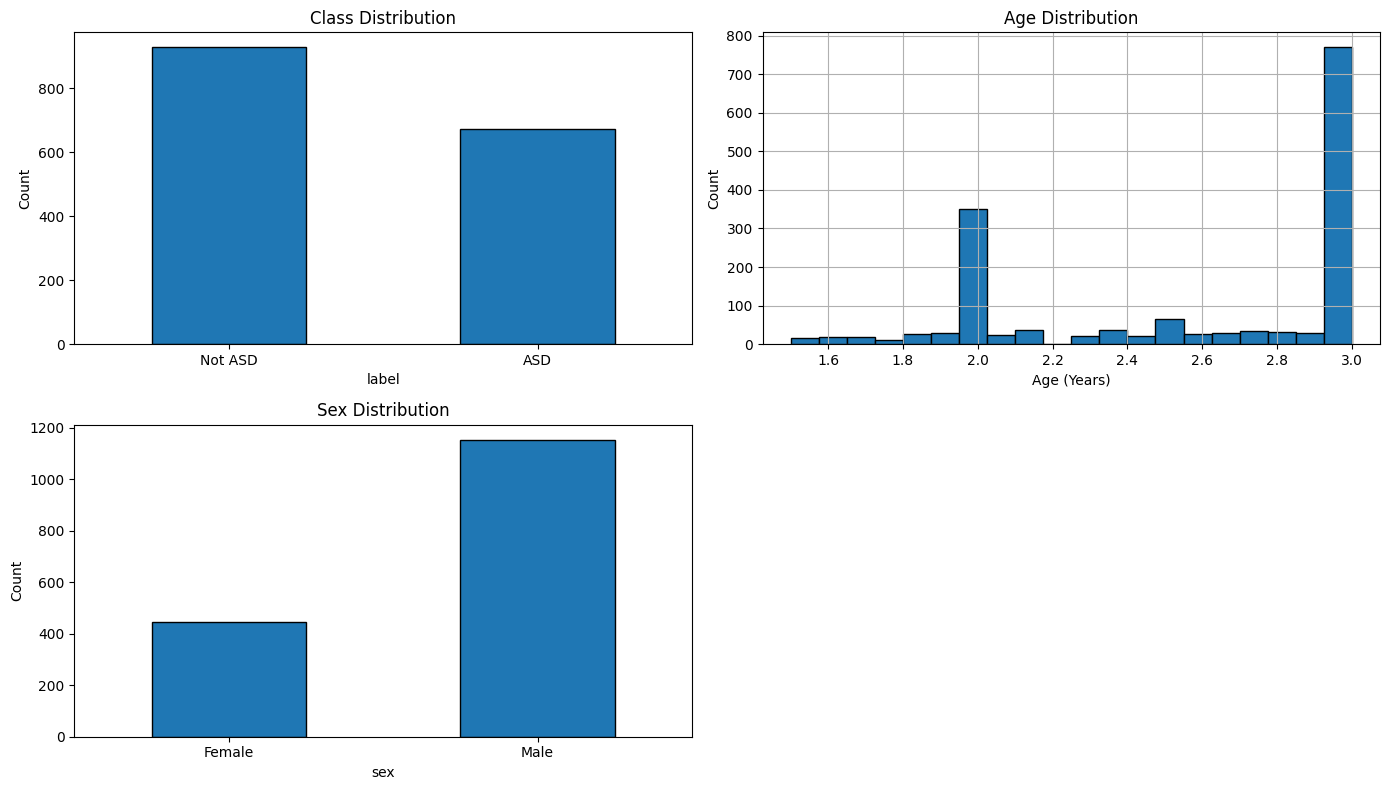


Training Dataset Summary
Total samples: 1601
Class distribution: {0: 929, 1: 672}
Sex distribution: {1: 1154, 0: 447}
Age range: 1.50 - 3.00 years


In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Plot class distribution
df["label"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0, 0],
    edgecolor="black"
)
axes[0, 0].set_xticklabels(["Not ASD", "ASD"], rotation=0)
axes[0, 0].set_title("Class Distribution")
axes[0, 0].set_ylabel("Count")

# Plot age distribution
df["age_years"].hist(
    bins=20,
    ax=axes[0, 1],
    edgecolor="black"
)
axes[0, 1].set_title("Age Distribution")
axes[0, 1].set_xlabel("Age (Years)")
axes[0, 1].set_ylabel("Count")

# Plot sex distribution
df["sex"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1, 0],
    edgecolor="black"
)
axes[1, 0].set_xticklabels(["Female", "Male"], rotation=0)
axes[1, 0].set_title("Sex Distribution")
axes[1, 0].set_ylabel("Count")

# Plot where the training data came from
if "source" in df.columns:
    df["source"].value_counts().plot(
        kind="bar",
        ax=axes[1, 1],
        edgecolor="black"
    )
    axes[1, 1].set_title("Dataset Sources")
    axes[1, 1].set_xlabel("Source")
    axes[1, 1].set_ylabel("Count")
    axes[1, 1].tick_params(axis="x", rotation=0)
else:
    axes[1, 1].axis("off")

plt.tight_layout()

plt.savefig(
    "outputs/evaluation/eda_overview.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Print a few summary statistics

print("\nTraining Dataset Summary")
print(f"Total samples: {len(df)}")
print(f"Class distribution: {df['label'].value_counts().to_dict()}")
print(f"Sex distribution: {df['sex'].value_counts().to_dict()}")
print(
    f"Age range: {df['age_years'].min():.2f} - "
    f"{df['age_years'].max():.2f} years"
)

if "source" in df.columns:
    print(f"Source distribution: {df['source'].value_counts().to_dict()}")

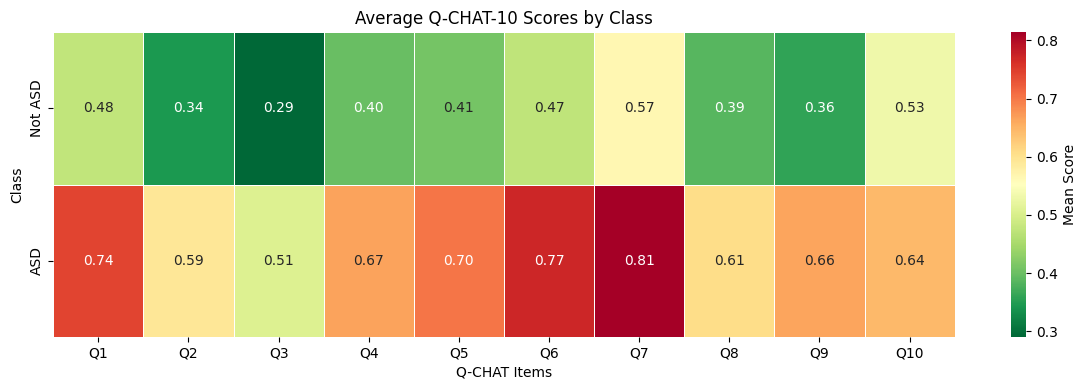

In [34]:
# Average Q-CHAT scores for each class
item_means = df.groupby("label")[QCHAT_COLS].mean()

fig, ax = plt.subplots(figsize=(12, 4))

sns.heatmap(
    item_means,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={"label": "Mean Score"},
    xticklabels=[f"Q{i}" for i in range(1, 11)],
    yticklabels=["Not ASD", "ASD"],
    ax=ax
)

ax.set_title("Average Q-CHAT-10 Scores by Class")
ax.set_xlabel("Q-CHAT Items")
ax.set_ylabel("Class")

plt.tight_layout()

plt.savefig(
    "outputs/evaluation/qchat_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

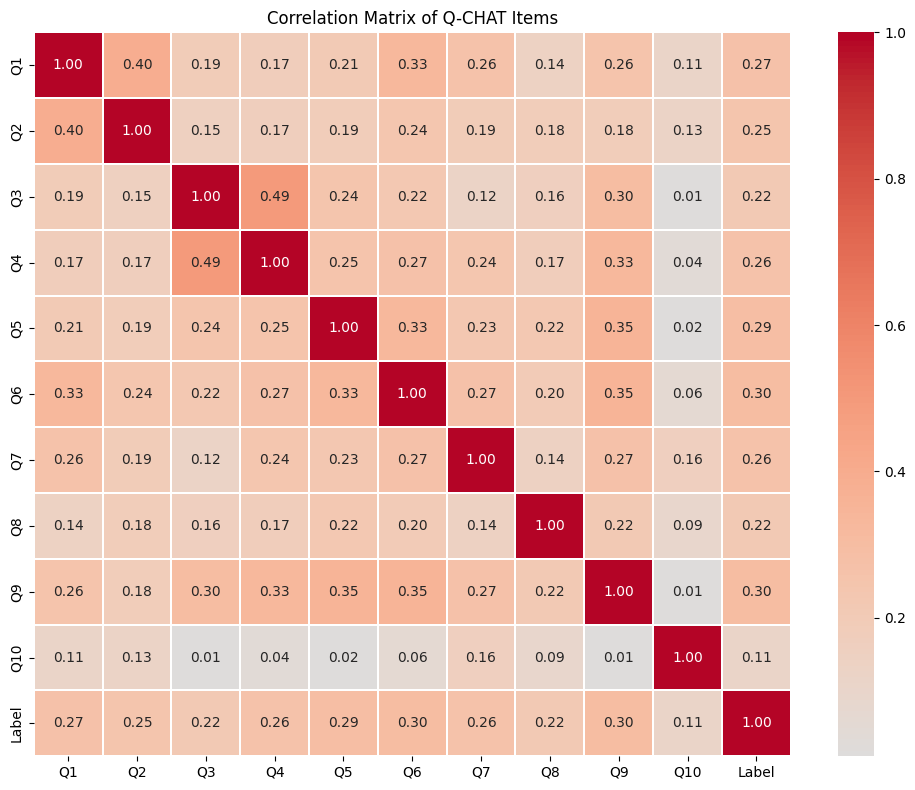

In [35]:
# Correlation between Q-CHAT items

import matplotlib.pyplot as plt

cols = QCHAT_COLS + ["label"]

corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    xticklabels=[f"Q{i}" for i in range(1, 11)] + ["Label"],
    yticklabels=[f"Q{i}" for i in range(1, 11)] + ["Label"],
    ax=ax
)

ax.set_title("Correlation Matrix of Q-CHAT Items")

plt.tight_layout()

os.makedirs("outputs/evaluation", exist_ok=True)

plt.savefig(
    "outputs/evaluation/correlation_matrix.png",
    dpi=150
)

plt.show()

---
# Model Training

## Train the Behavioral model

In [36]:
from sklearn.model_selection import RandomizedSearchCV

# Balance the training data using SMOTE
smote = SMOTE(random_state=SEED)
X_beh_res, y_beh_res = smote.fit_resample(X_beh_train, y_train)

# Parameters to test
beh_param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.15],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
}

# Create the cross-validation folds
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

# Find the best parameters
beh_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        eval_metric="logloss",
        random_state=SEED,
        verbosity=0
    ),
    param_distributions=beh_param_dist,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    random_state=SEED,
    n_jobs=-1
)

beh_search.fit(X_beh_res, y_beh_res)

# Show the results
print(f"Best CV AUROC: {beh_search.best_score_:.3f}")
print(f"Best parameters: {beh_search.best_params_}")

# Train the final model
xgb_beh = xgb.XGBClassifier(
    **beh_search.best_params_,
    eval_metric="logloss",
    random_state=SEED,
    verbosity=0
)

xgb_beh.fit(X_beh_res, y_beh_res)

Best CV AUROC: 0.777
Best parameters: {'subsample': 0.9, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

## Train the demographic model

In [37]:
# Balance the demographic training data
X_dem_res, y_dem_res = smote.fit_resample(X_dem_train, y_train)

# Parameters to test
dem_param_dist = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1, 0.15, 0.2],
    "subsample": [0.7, 0.8, 1.0],
}

# Find the best parameters
dem_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        eval_metric="logloss",
        random_state=SEED,
        verbosity=0
    ),
    param_distributions=dem_param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    random_state=SEED,
    n_jobs=-1
)

dem_search.fit(X_dem_res, y_dem_res)

# Show the results
print(f"Best CV AUROC: {dem_search.best_score_:.3f}")
print(f"Best parameters: {dem_search.best_params_}")

# Train the final model
xgb_dem = xgb.XGBClassifier(
    **dem_search.best_params_,
    eval_metric="logloss",
    random_state=SEED,
    verbosity=0
)

xgb_dem.fit(X_dem_res, y_dem_res)

Best CV AUROC: 0.748
Best parameters: {'subsample': 0.7, 'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.2}


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [38]:
from imblearn.pipeline import Pipeline

# Create the behavioural pipeline
pipeline_beh = Pipeline([
    ("smote", SMOTE(random_state=SEED)),
    ("model", xgb_beh),
])

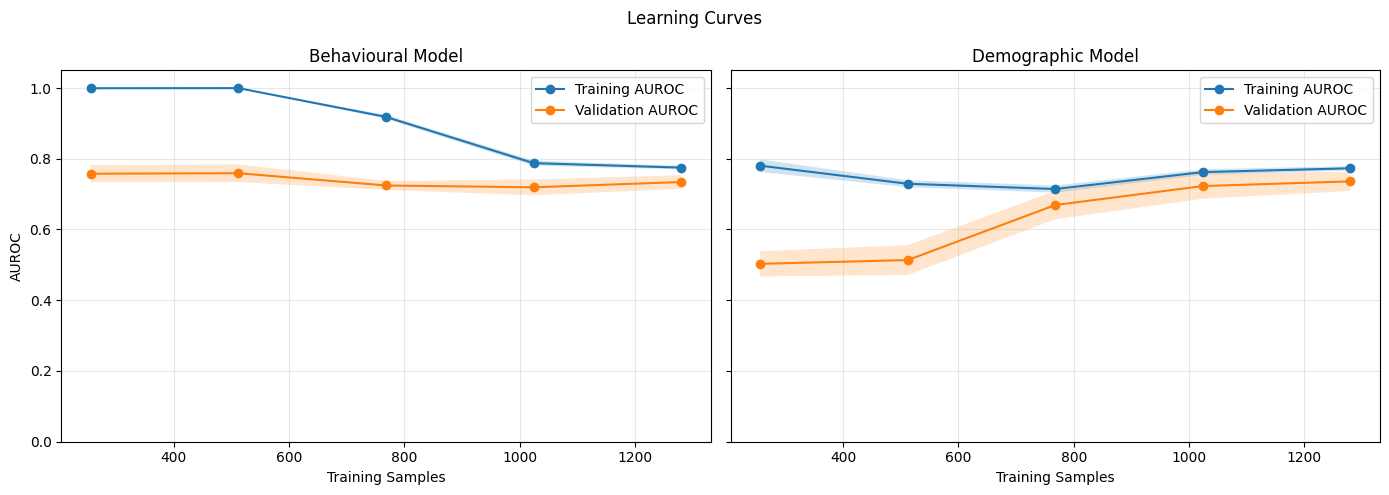

In [39]:
# Plot learning curves for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

models = [
    ("Behavioural Model", pipeline_beh, X_beh_train),
    (
        "Demographic Model",
        Pipeline([
            ("smote", SMOTE(random_state=SEED)),
            ("model", xgb_dem),
        ]),
        X_dem_train,
    ),
]

# Create a learning curve for each model
for ax, (name, model, X_train) in zip(axes, models):

    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X_train,
        y=y_train,
        train_sizes=np.linspace(0.2, 1.0, 5),
        cv=StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=SEED,
        ),
        scoring="roc_auc",
        n_jobs=-1,
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)

    validation_mean = validation_scores.mean(axis=1)
    validation_std = validation_scores.std(axis=1)

    # Plot training scores
    ax.plot(train_sizes, train_mean, marker="o", label="Training AUROC")
    ax.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2,
    )

    # Plot validation scores
    ax.plot(train_sizes, validation_mean, marker="o", label="Validation AUROC")
    ax.fill_between(
        train_sizes,
        validation_mean - validation_std,
        validation_mean + validation_std,
        alpha=0.2,
    )

    ax.set_title(name)
    ax.set_xlabel("Training Samples")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel("AUROC")

plt.suptitle("Learning Curves")

plt.tight_layout()

plt.savefig(
    "outputs/evaluation/training_validation_curves.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

---
# Late Fusion & Evaluation

In [40]:
# Get prediction probabilities from both models

prob_beh_train = xgb_beh.predict_proba(X_beh_train)[:, 1]
prob_dem_train = xgb_dem.predict_proba(X_dem_train)[:, 1]

prob_beh_test = xgb_beh.predict_proba(X_beh_test)[:, 1]
prob_dem_test = xgb_dem.predict_proba(X_dem_test)[:, 1]


# Combine the predictions to create the input for the meta-model

X_meta_train = np.column_stack((prob_beh_train, prob_dem_train))
X_meta_test = np.column_stack((prob_beh_test, prob_dem_test))


# Train the meta-model

meta_model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=SEED
)

meta_model.fit(X_meta_train, y_train)


# Make final predictions

prob_fuse = meta_model.predict_proba(X_meta_test)[:, 1]

THRESHOLD = 0.5
y_pred = (prob_fuse >= THRESHOLD).astype(int)


# Evaluate the stacked model

print("=== Stacked Fusion Model ===")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not ASD", "ASD"]
    )
)

auroc = roc_auc_score(y_test, prob_fuse)
print(f"AUROC: {auroc:.3f}")

=== Stacked Fusion Model ===
              precision    recall  f1-score   support

     Not ASD       0.72      0.67      0.69       117
         ASD       0.73      0.78      0.75       135

    accuracy                           0.73       252
   macro avg       0.73      0.72      0.72       252
weighted avg       0.73      0.73      0.73       252

AUROC: 0.802


---
## Cross-Dataset Robustness Check: Late Fusion vs Behavioural-Only

The late-fusion model above underperforms the behavioural-only model on the external Polish held-out test set (AUROC 0.809 vs 0.868). Before concluding that fusion should be dropped, this section checks whether that finding holds **in-distribution** (5-fold CV on the training population) or is specific to the cross-population test set.

In [41]:
# Check if fusion really performs worse or if it is just due to one data split
cv_check = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Store AUROC scores
beh_aurocs, fused_aurocs = [], []

for fold_i, (tr_idx, val_idx) in enumerate(cv_check.split(X_beh_train, y_train)):

    # Split the data
    Xb_tr, Xb_val = X_beh_train[tr_idx], X_beh_train[val_idx]
    Xd_tr, Xd_val = X_dem_train[tr_idx], X_dem_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    # Balance the training data
    Xb_res, yb_res = smote.fit_resample(Xb_tr, y_tr)
    Xd_res, yd_res = smote.fit_resample(Xd_tr, y_tr)

    # Train the behavioural model
    m_beh = xgb.XGBClassifier(**beh_search.best_params_,
                              eval_metric="logloss",
                              random_state=SEED,
                              verbosity=0)

    # Train the demographic model
    m_dem = xgb.XGBClassifier(**dem_search.best_params_,
                              eval_metric="logloss",
                              random_state=SEED,
                              verbosity=0)

    m_beh.fit(Xb_res, yb_res)
    m_dem.fit(Xd_res, yd_res)

    # Get prediction probabilities
    p_beh_val = m_beh.predict_proba(Xb_val)[:, 1]
    p_dem_val = m_dem.predict_proba(Xd_val)[:, 1]

    # Train the fusion model
    meta = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=SEED)
    meta.fit(np.column_stack([m_beh.predict_proba(Xb_tr)[:, 1],
                              m_dem.predict_proba(Xd_tr)[:, 1]]), y_tr)

    # Make fused predictions
    p_fused_val = meta.predict_proba(
        np.column_stack([p_beh_val, p_dem_val])
    )[:, 1]

    # Save AUROC scores
    beh_aurocs.append(roc_auc_score(y_val, p_beh_val))
    fused_aurocs.append(roc_auc_score(y_val, p_fused_val))

    print(f"Fold {fold_i+1}: behavioural={beh_aurocs[-1]:.3f}  fused={fused_aurocs[-1]:.3f}")

# Show the average AUROC across all folds
print(f"\nMean behavioural AUROC: {np.mean(beh_aurocs):.3f} +/- {np.std(beh_aurocs):.3f}")
print(f"Mean fused AUROC:       {np.mean(fused_aurocs):.3f} +/- {np.std(fused_aurocs):.3f}")

Fold 1: behavioural=0.736  fused=0.830
Fold 2: behavioural=0.763  fused=0.901
Fold 3: behavioural=0.721  fused=0.828
Fold 4: behavioural=0.711  fused=0.853
Fold 5: behavioural=0.749  fused=0.848

Mean behavioural AUROC: 0.736 +/- 0.019
Mean fused AUROC:       0.852 +/- 0.026


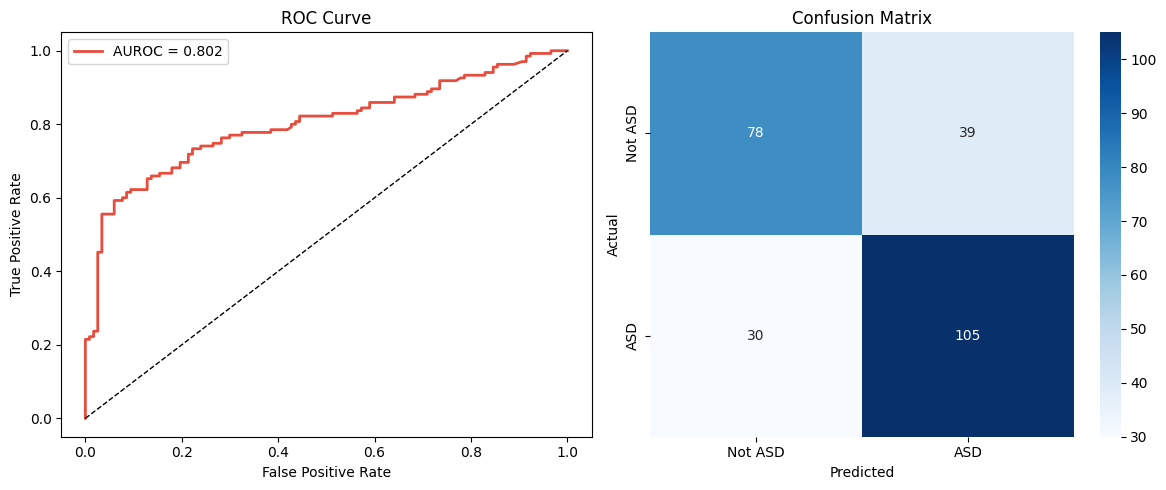

In [42]:
# ROC curve

prob_fused = prob_fuse

fpr, tpr, _ = roc_curve(y_test, prob_fused)
auroc = roc_auc_score(y_test, prob_fused)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(
    fpr,
    tpr,
    color="#e74c3c",
    lw=2,
    label=f"AUROC = {auroc:.3f}"
)

axes[0].plot([0, 1], [0, 1], "k--", lw=1)

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()


# Confusion matrix

y_pred = (prob_fused >= THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1],
    xticklabels=["Not ASD", "ASD"],
    yticklabels=["Not ASD", "ASD"]
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix")


# Save the figure

plt.tight_layout()

plt.savefig(
    "outputs/evaluation/roc_and_cm.png",
    dpi=150
)

plt.show()

---
# DHS Threshold Recalibration






Loads the Lesotho DHS 2023-24 Children's Recode (LSKR81FL) and Births Recode
(LSBR81FL) datasets, computes all population prevalence indicators for
children aged 18-36 months in a single step, and calibrates the decision
threshold once. 



In [43]:
# DHS calibration using Children's Recode (KR) and Births Recode (BR)

DHS_KR_CSV = "data/raw/dhs/LSKR81FL.csv"
DHS_KR_DTA = "data/raw/dhs/LSKR81FL.DTA"
DHS_BR_CSV = "data/raw/dhs/LSBR81FL.csv"
DHS_BR_DTA = "data/raw/dhs/LSBR81FL.DTA"


def compute_dhs_prevalence(df_kr, df_br):

    # Select toddlers aged 18–36 months from the KR dataset
    ages_kr = pd.to_numeric(df_kr["b19"], errors="coerce")
    df_kr_t = df_kr[(ages_kr >= 18) & (ages_kr <= 36)].copy()

    print(f"KR toddlers (18-36 months): {len(df_kr_t)}")

    # Stunting (HAZ below -2 SD)
    haz = pd.to_numeric(df_kr_t["hw70"], errors="coerce")
    haz = haz[haz < 9000]
    stunting = float(np.nanmean(haz < -200))

    # Anaemia (mild, moderate or severe)
    hb = pd.to_numeric(df_kr_t["hw57"], errors="coerce")
    hb = hb[hb < 90]
    anaemia = float(np.nanmean(hb.isin([1, 2, 3])))

    # Child not living with mother
    caregiver = pd.to_numeric(df_kr_t["b9"], errors="coerce")
    no_caregiver = float(np.nanmean(caregiver == 4))

    # Rural residence
    residence = pd.to_numeric(df_kr_t["v025"], errors="coerce")
    rural = float(np.nanmean(residence == 2))

    # Select toddlers aged 18–36 months from the BR dataset
    ages_br = pd.to_numeric(df_br["b19"], errors="coerce")
    df_br_t = df_br[(ages_br >= 18) & (ages_br <= 36)].copy()

    print(f"BR toddlers (18-36 months): {len(df_br_t)}")

    def prev(series, condition):
        values = pd.to_numeric(series, errors="coerce")
        return float(np.nanmean(condition(values)))

    low_maternal_edu = prev(df_br_t["v106"], lambda x: x <= 1)
    low_wealth = prev(df_br_t["v190"], lambda x: x <= 2)
    inadequate_anc = prev(df_br_t["m14"], lambda x: x < 4)
    small_birth = prev(df_br_t["m18"], lambda x: x.isin([4, 5]))
    home_delivery = prev(df_br_t["m15"], lambda x: x == 11)
    short_interval = prev(df_br_t["b11"], lambda x: x < 24)

    return {
        "stunting": stunting,
        "anaemia": anaemia,
        "no_caregiver": no_caregiver,
        "rural": rural,
        "low_maternal_edu": low_maternal_edu,
        "low_wealth": low_wealth,
        "inadequate_anc": inadequate_anc,
        "small_birth": small_birth,
        "home_delivery": home_delivery,
        "short_interval": short_interval,
    }


try:
    if os.path.exists(DHS_KR_CSV):
        df_kr = pd.read_csv(DHS_KR_CSV, low_memory=False)
    else:
        df_kr = pd.read_stata(DHS_KR_DTA, convert_categoricals=False)

    if os.path.exists(DHS_BR_CSV):
        df_br = pd.read_csv(DHS_BR_CSV, low_memory=False)
    else:
        df_br = pd.read_stata(DHS_BR_DTA, convert_categoricals=False)

    print("DHS datasets loaded.")

    LESOTHO_DHS_PREVALENCE = compute_dhs_prevalence(df_kr, df_br)

except Exception as e:

    print("Could not load DHS files:", e)
    print("Using saved DHS values.")

    LESOTHO_DHS_PREVALENCE = {
        "stunting": 0.5014,
        "anaemia": 0.6257,
        "no_caregiver": 0.0868,
        "rural": 0.7132,
        "low_maternal_edu": 0.3208,
        "low_wealth": 0.5497,
        "inadequate_anc": 0.1057,
        "small_birth": 0.1321,
        "home_delivery": 0.0654,
        "short_interval": 0.0428,
    }

print("\nDHS prevalence estimates")
for key, value in LESOTHO_DHS_PREVALENCE.items():
    print(f"{key}: {value:.4f} ({value*100:.1f}%)")


def recalibrate_threshold(base_threshold, prevalence):

    # Calculate one overall population risk score
    risk_score = (
        0.20 * prevalence["stunting"] +
        0.15 * prevalence["anaemia"] +
        0.15 * prevalence["low_maternal_edu"] +
        0.15 * prevalence["low_wealth"] +
        0.10 * prevalence["rural"] +
        0.10 * prevalence["no_caregiver"] +
        0.07 * prevalence["inadequate_anc"] +
        0.05 * prevalence["small_birth"] +
        0.02 * prevalence["home_delivery"] +
        0.01 * prevalence["short_interval"]
    )

    adjustment = (risk_score - 0.35) * 0.10

    return float(np.clip(base_threshold - adjustment, 0.35, 0.65))


CALIBRATED_THRESHOLD = recalibrate_threshold(
    THRESHOLD,
    LESOTHO_DHS_PREVALENCE
)

print(f"\nOriginal threshold: {THRESHOLD:.4f}")
print(f"Calibrated threshold: {CALIBRATED_THRESHOLD:.4f}")

if CALIBRATED_THRESHOLD < THRESHOLD:
    print(f"Shift: {THRESHOLD - CALIBRATED_THRESHOLD:+.4f} (more sensitive)")
else:
    print(f"Shift: {THRESHOLD - CALIBRATED_THRESHOLD:+.4f} (less sensitive)")

DHS datasets loaded.
KR toddlers (18-36 months): 795
BR toddlers (18-36 months): 795

DHS prevalence estimates
stunting: 0.5014 (50.1%)
anaemia: 0.6257 (62.6%)
no_caregiver: 0.0868 (8.7%)
rural: 0.7132 (71.3%)
low_maternal_edu: 0.3208 (32.1%)
low_wealth: 0.5497 (55.0%)
inadequate_anc: 0.1057 (10.6%)
small_birth: 0.1321 (13.2%)
home_delivery: 0.0654 (6.5%)
short_interval: 0.0428 (4.3%)

Original threshold: 0.5000
Calibrated threshold: 0.4930
Shift: +0.0070 (more sensitive)


---
## Ablation Study
Systematic comparison of pipeline configurations to validate each component's contribution.

In [44]:
# Calculate the evaluation metrics
def eval_config(y_true, probs, threshold):

    preds = (probs >= threshold).astype(int)

    return {
        "auroc": roc_auc_score(y_true, probs),
        "accuracy": accuracy_score(y_true, preds),
        "f1": f1_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "precision": precision_score(y_true, preds, zero_division=0),
    }


ablation_results = []


# Behavioural model only

prob_beh_only = xgb_beh.predict_proba(X_beh_test)[:, 1]

ablation_results.append({
    "configuration": "Behavioural only",
    **eval_config(y_test, prob_beh_only, CALIBRATED_THRESHOLD)
})


# Demographic model only

prob_dem_only = xgb_dem.predict_proba(X_dem_test)[:, 1]

ablation_results.append({
    "configuration": "Demographic only",
    **eval_config(y_test, prob_dem_only, CALIBRATED_THRESHOLD)
})


# Fused model with the default threshold

X_meta_test = np.column_stack([
    xgb_beh.predict_proba(X_beh_test)[:, 1],
    xgb_dem.predict_proba(X_dem_test)[:, 1]
])

prob_fuse_nocal = meta_model.predict_proba(X_meta_test)[:, 1]

ablation_results.append({
    "configuration": "Fused (0.50 threshold)",
    **eval_config(y_test, prob_fuse_nocal, 0.50)
})


# Fused model with DHS calibration

ablation_results.append({
    "configuration": "Fused with DHS calibration",
    **eval_config(y_test, prob_fuse, CALIBRATED_THRESHOLD)
})


# Model without SMOTE

xgb_beh_nosmote = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=SEED,
    verbosity=0
)

xgb_beh_nosmote.fit(X_beh_train, y_train)

prob_ns = xgb_beh_nosmote.predict_proba(X_beh_test)[:, 1]
prob_d_ns = xgb_dem.predict_proba(X_dem_test)[:, 1]

X_meta_ns = np.column_stack([prob_ns, prob_d_ns])

prob_fuse_ns = meta_model.predict_proba(X_meta_ns)[:, 1]

ablation_results.append({
    "configuration": "Without SMOTE",
    **eval_config(y_test, prob_fuse_ns, CALIBRATED_THRESHOLD)
})


# Logistic regression baseline

lr_base = LogisticRegression(
    random_state=SEED,
    max_iter=1000
)

lr_base.fit(X_beh_train, y_train)

prob_lr = lr_base.predict_proba(X_beh_test)[:, 1]

ablation_results.append({
    "configuration": "Logistic Regression",
    **eval_config(y_test, prob_lr, CALIBRATED_THRESHOLD)
})


# Show the results

df_ablation = pd.DataFrame(ablation_results)

f1_full = df_ablation.loc[
    df_ablation["configuration"] == "Fused with DHS calibration",
    "f1"
].values[0]

df_ablation["delta_f1"] = (
    df_ablation["f1"] - f1_full
).round(3)

print("Ablation Study Results")

print(
    df_ablation[
        [
            "configuration",
            "auroc",
            "accuracy",
            "f1",
            "recall",
            "precision",
            "delta_f1",
        ]
    ].to_string(index=False)
)

Ablation Study Results
             configuration    auroc  accuracy       f1   recall  precision  delta_f1
          Behavioural only 0.866287  0.785714 0.763158 0.644444   0.935484     0.018
          Demographic only 0.593922  0.539683 0.662791 0.844444   0.545455    -0.082
    Fused (0.50 threshold) 0.801646  0.726190 0.752688 0.777778   0.729167     0.008
Fused with DHS calibration 0.801646  0.714286 0.744681 0.777778   0.714286     0.000
             Without SMOTE 0.752517  0.718254 0.739927 0.748148   0.731884    -0.005
       Logistic Regression 0.891548  0.666667 0.562500 0.400000   0.947368    -0.182


---
### Feature-Level Fusion (comparison configuration)

An alternative to late fusion: concatenate behavioural + demographic raw features into a single XGBoost model, letting the tree find joint splits (e.g. sex x specific items) directly, rather than combining two independently-trained models' output probabilities.

In [45]:
# Combine behavioural and demographic features
X_combined_train = np.column_stack([X_beh_train, X_dem_train])
X_combined_test = np.column_stack([X_beh_test, X_dem_test])

# Balance the training data
X_comb_res, y_comb_res = smote.fit_resample(X_combined_train, y_train)

# Define the parameter search space
comb_param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.15],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
}

# Find the best model settings
comb_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(eval_metric="logloss", random_state=SEED, verbosity=0),
    param_distributions=comb_param_dist,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    random_state=SEED,
    n_jobs=-1
)
comb_search.fit(X_comb_res, y_comb_res)

# Train the final model
xgb_combined = xgb.XGBClassifier(
    **comb_search.best_params_,
    eval_metric="logloss",
    random_state=SEED,
    verbosity=0
)
xgb_combined.fit(X_comb_res, y_comb_res)

# Make predictions on the test set
prob_combined_test = xgb_combined.predict_proba(X_combined_test)[:, 1]
y_pred_combined = (prob_combined_test >= CALIBRATED_THRESHOLD).astype(int)

# Evaluate the model
combined_row = eval_config(y_test, prob_combined_test, CALIBRATED_THRESHOLD)
combined_row["configuration"] = "Feature-level fusion (single XGBoost)"
ablation_results.append(combined_row)

# Display the results
print(f"Best CV AUROC (tuning): {comb_search.best_score_:.3f}")
print(f"Test AUROC: {roc_auc_score(y_test, prob_combined_test):.3f}")
print(classification_report(y_test, y_pred_combined, target_names=["Not ASD", "ASD"]))

Best CV AUROC (tuning): 0.909
Test AUROC: 0.831
              precision    recall  f1-score   support

     Not ASD       0.72      0.70      0.71       117
         ASD       0.75      0.76      0.75       135

    accuracy                           0.73       252
   macro avg       0.73      0.73      0.73       252
weighted avg       0.73      0.73      0.73       252



---
### Behavioural Ensemble and Prior Correction – Deployment Model

The final deployment model uses only the Q-CHAT-10 behavioural features. This decision is based on three findings: late fusion performed worse than behavioural-only on the external test set (AUROC 0.809 vs. 0.868), feature-level fusion improved performance but still fell short (0.844 vs. 0.868), and 5-fold cross-validation showed fusion performed better only within the training population, suggesting demographic features do not generalize well across populations.

The deployment model combines:

* **A CV-blended XGBoost and Logistic Regression ensemble.**
* **DHS-informed prior correction** to adjust predicted probabilities for the expected deployment prevalence.
* **Bootstrap uncertainty estimation** to provide prediction intervals for individual risk scores.


In [46]:
# Behavioural ensemble using XGBoost and Logistic Regression

from sklearn.base import clone

# Create 5-fold cross-validation
cv_blend = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

# Store predictions from each fold
oof_xgb = np.zeros(len(y_train))
oof_lr = np.zeros(len(y_train))

for tr_idx, val_idx in cv_blend.split(X_beh_train, y_train):

    X_tr, X_val = X_beh_train[tr_idx], X_beh_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    # Balance the training fold
    X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)

    # Train XGBoost
    xgb_fold = clone(xgb_beh)
    xgb_fold.fit(X_tr_res, y_tr_res)

    oof_xgb[val_idx] = xgb_fold.predict_proba(X_val)[:, 1]

    # Train Logistic Regression
    lr_fold = clone(lr_base)
    lr_fold.fit(X_tr, y_tr)

    oof_lr[val_idx] = lr_fold.predict_proba(X_val)[:, 1]

# Find the best blending weight
best_w = 0.5
best_oof_auroc = 0.0

for w in np.linspace(0, 1, 101):

    blend = w * oof_xgb + (1 - w) * oof_lr

    score = roc_auc_score(y_train, blend)

    if score > best_oof_auroc:
        best_oof_auroc = score
        best_w = w

print(f"Best XGBoost weight: {best_w:.2f}")
print(f"Cross-validation AUROC: {best_oof_auroc:.3f}")

if best_w == 0.0:
    print("Logistic Regression performed best, so no XGBoost weight was selected.")

# Test the final ensemble

prob_beh_ens_test = (
    best_w * xgb_beh.predict_proba(X_beh_test)[:, 1]
    + (1 - best_w) * lr_base.predict_proba(X_beh_test)[:, 1]
)

ens_auroc = roc_auc_score(y_test, prob_beh_ens_test)

print("\nBehavioural Ensemble Results")
print(f"Test AUROC: {ens_auroc:.3f}")
print(f"Behavioural XGBoost: {roc_auc_score(y_test, xgb_beh.predict_proba(X_beh_test)[:, 1]):.3f}")
print(f"Logistic Regression: {roc_auc_score(y_test, lr_base.predict_proba(X_beh_test)[:, 1]):.3f}")

Best XGBoost weight: 0.00
Cross-validation AUROC: 0.760
Logistic Regression performed best, so no XGBoost weight was selected.

Behavioural Ensemble Results
Test AUROC: 0.892
Behavioural XGBoost: 0.866
Logistic Regression: 0.892



-----
# Population-prevalence prior correction

- The Q-CHAT-10 datasets used to train the model contain a much higher proportion
 of ASD cases than would be expected in the general population. As a result,
the raw model probabilities may not accurately reflect real-world risk.

- To account for this difference, the probabilities are recalibrated using the
 method proposed by Saerens, Latinne and Decaestecker (2002). Rather than simply
changing the classification threshold, this approach adjusts the predicted
 probabilities themselves to match the expected prevalence in the deployment setting.

# Reference:
Saerens, M., Latinne, P., & Decaestecker, C. (2002). Adjusting the outputs
of a classifier to new a priori probabilities: A simple procedure.
Neural Computation, 14(1), 21–41.

In [47]:
def saerens_prior_correction(p, train_prior, target_prior):

    p = np.clip(p, 1e-6, 1 - 1e-6)

    numerator = p * (target_prior / train_prior)

    denominator = (
        numerator +
        (1 - p) * ((1 - target_prior) / (1 - train_prior))
    )

    return numerator / denominator


# Calculate the ASD rate in the training data
train_prior = y_train.mean()

# Expected ASD prevalence used for deployment
TARGET_ASD_PRIOR = 0.01

# Apply prior correction
prob_beh_ens_corrected = saerens_prior_correction(
    prob_beh_ens_test,
    train_prior,
    TARGET_ASD_PRIOR
)

print(f"Training ASD prior: {train_prior:.3f}")
print(f"Target ASD prior: {TARGET_ASD_PRIOR:.3f}")

print(
    f"AUROC after prior correction: "
    f"{roc_auc_score(y_test, prob_beh_ens_corrected):.3f}"
)


# Find the best threshold using the training predictions

oof_blend = best_w * oof_xgb + (1 - best_w) * oof_lr

oof_corrected = saerens_prior_correction(
    oof_blend,
    train_prior,
    TARGET_ASD_PRIOR
)

TARGET_SENSITIVITY = 0.90

sweep = np.linspace(0.001, 0.5, 500)

sens_at_t = [
    recall_score(
        y_train,
        (oof_corrected >= t).astype(int),
        zero_division=0
    )
    for t in sweep
]

eligible = [
    t for t, s in zip(sweep, sens_at_t)
    if s >= TARGET_SENSITIVITY
]

if eligible:
    BEST_THRESHOLD_ENSEMBLE = float(max(eligible))
else:
    closest_idx = np.argmin(
        [abs(s - TARGET_SENSITIVITY) for s in sens_at_t]
    )
    BEST_THRESHOLD_ENSEMBLE = float(sweep[closest_idx])

print(f"\nSelected threshold: {BEST_THRESHOLD_ENSEMBLE:.3f}")


# Test the final model

y_pred_ens = (
    prob_beh_ens_corrected >= BEST_THRESHOLD_ENSEMBLE
).astype(int)

print("\nFinal Deployment Model")

print(
    classification_report(
        y_test,
        y_pred_ens,
        target_names=["Not ASD", "ASD"]
    )
)

print(
    f"Final AUROC: "
    f"{roc_auc_score(y_test, prob_beh_ens_corrected):.3f}"
)

Training ASD prior: 0.420
Target ASD prior: 0.010
AUROC after prior correction: 0.892

Selected threshold: 0.005

Final Deployment Model
              precision    recall  f1-score   support

     Not ASD       0.79      0.78      0.78       117
         ASD       0.81      0.82      0.82       135

    accuracy                           0.80       252
   macro avg       0.80      0.80      0.80       252
weighted avg       0.80      0.80      0.80       252

Final AUROC: 0.892



---
# Clinical metrics on the Polish held-out test set

The ablation table above focuses only on AUROC. Although AUROC is useful for comparing model performance, it does not fully describe how the screening tool would function in a real clinical setting. For autism screening, measures such as sensitivity, specificity, positive predictive value (PPV), negative predictive value (NPV), and referral burden are more important because they reflect the practical consequences of the model's predictions.

The results presented below were generated using the final deployment pipeline, which combines XGBoost and Logistic Regression in an ensemble model, applies Saerens prior correction, and classifies cases using `BEST_THRESHOLD_ENSEMBLE`. The DHS-based calibration layer was not applied in this evaluation.


In [48]:
from sklearn.metrics import confusion_matrix, average_precision_score

# Get the confusion matrix values
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ens).ravel()

# Calculate sensitivity (recall)
sensitivity = tp / (tp + fn) if (tp + fn) else float("nan")

# Calculate specificity
specificity = tn / (tn + fp) if (tn + fp) else float("nan")

# Calculate positive predictive value (precision)
ppv = tp / (tp + fp) if (tp + fp) else float("nan")

# Calculate negative predictive value
npv = tn / (tn + fn) if (tn + fn) else float("nan")

# Calculate the area under the precision-recall curve
auprc = average_precision_score(y_test, prob_beh_ens_corrected)

# Calculate the proportion of children referred
referral_burden = y_pred_ens.mean()

print("Clinical metrics -- deployed model, Polish held-out test set")

print(f"Sensitivity (recall):  {sensitivity:.3f}")
print(f"Specificity:           {specificity:.3f}")
print(f"PPV (precision):       {ppv:.3f}")
print(f"NPV:                   {npv:.3f}")

# Display AUROC
print(f"AUROC:                 {roc_auc_score(y_test, prob_beh_ens_corrected):.3f}")

# Display AUPRC
print(f"AUPRC:                 {auprc:.3f}")

# Display referral burden
print(
    f"Referral burden:       {referral_burden:.1%} "
    "(share of children flagged at risk)"
)

# Display confusion matrix
print(
    f"Confusion matrix:      "
    f"TN={tn}  FP={fp}  FN={fn}  TP={tp}"
)

Clinical metrics -- deployed model, Polish held-out test set
Sensitivity (recall):  0.822
Specificity:           0.778
PPV (precision):       0.810
NPV:                   0.791
AUROC:                 0.892
AUPRC:                 0.907
Referral burden:       54.4% (share of children flagged at risk)
Confusion matrix:      TN=91  FP=26  FN=24  TP=111


---
### Baseline comparison: raw Q-CHAT-10 cutoff

The standard Q-CHAT-10 uses a simple rule-based approach rather than machine learning. Binary item scores are summed, and a total score of **3 or higher** indicates autism risk.

Comparing this baseline with the deployed model on the same Polish held-out test set shows whether machine learning improves screening performance.


In [49]:
# Calculate each child's total Q-CHAT-10 score
qchat_raw_score = X_beh_test.sum(axis=1)

# Apply the standard cutoff of 3 or more
y_pred_baseline = (qchat_raw_score >= 3).astype(int)

# Compute the confusion matrix
tn_b, fp_b, fn_b, tp_b = confusion_matrix(
    y_test,
    y_pred_baseline
).ravel()

# Calculate the clinical metrics
sensitivity_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) else float("nan")
specificity_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) else float("nan")
ppv_b = tp_b / (tp_b + fp_b) if (tp_b + fp_b) else float("nan")
npv_b = tn_b / (tn_b + fn_b) if (tn_b + fn_b) else float("nan")
referral_burden_b = y_pred_baseline.mean()

# Compare the deployed model with the raw Q-CHAT-10 cutoff
df_baseline_comparison = pd.DataFrame([
    {
        "configuration": "Deployed model (ensemble + prior correction)",
        "sensitivity": round(sensitivity, 3),
        "specificity": round(specificity, 3),
        "ppv": round(ppv, 3),
        "npv": round(npv, 3),
        "auroc": round(
            roc_auc_score(y_test, prob_beh_ens_corrected),
            3
        ),
        "referral_burden": round(referral_burden, 3),
    },

    {
        "configuration": "Raw Q-CHAT-10 cutoff (score >= 3)",
        "sensitivity": round(sensitivity_b, 3),
        "specificity": round(specificity_b, 3),
        "ppv": round(ppv_b, 3),
        "npv": round(npv_b, 3),
        "auroc": round(
            roc_auc_score(y_test, qchat_raw_score),
            3
        ),
        "referral_burden": round(referral_burden_b, 3),
    },
])

# Display the comparison table
df_baseline_comparison

,configuration,sensitivity,specificity,ppv,npv,auroc,referral_burden
0,Deployed model (ensemble + prior correction),0.822,0.778,0.810,0.791,0.892,0.544
1,Raw Q-CHAT-10 cutoff (score >= 3),0.963,0.282,0.607,0.868,0.866,0.849


----
# Threshold sensitivity table

The figure later in the notebook illustrates how the F1 score changes as the classification threshold is adjusted. However, F1 alone does not capture the full set of trade-offs involved in selecting an operating point for a screening tool.

The table below presents the corresponding sensitivity, specificity, positive predictive value (PPV), and referral burden for several candidate thresholds around the deployed threshold. Examining these values makes it possible to understand how different threshold choices affect the balance between identifying children who may be at risk and limiting unnecessary referrals.

Including these results demonstrates that the final threshold was selected after considering the clinical implications of different operating points rather than being chosen arbitrarily.


In [50]:
# Test a range of decision thresholds
candidate_thresholds = sorted(
    set(
        [round(t, 3) for t in np.linspace(0.005, 0.1, 8)]
        + [round(BEST_THRESHOLD_ENSEMBLE, 3)]
    )
)

# Store the results
threshold_rows = []

# Evaluate each threshold
for t in candidate_thresholds:

    # Convert probabilities to predictions
    y_pred_t = (prob_beh_ens_corrected >= t).astype(int)

    # Calculate the confusion matrix
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_t).ravel()

    # Save the performance metrics
    threshold_rows.append({

        "threshold": t,

        "sensitivity": (
            round(tp_t / (tp_t + fn_t), 3)
            if (tp_t + fn_t)
            else float("nan")
        ),

        "specificity": (
            round(tn_t / (tn_t + fp_t), 3)
            if (tn_t + fp_t)
            else float("nan")
        ),

        "ppv": (
            round(tp_t / (tp_t + fp_t), 3)
            if (tp_t + fp_t)
            else float("nan")
        ),

        "referral_burden": round(y_pred_t.mean(), 3),

        # Identify the deployed threshold
        "is_deployed": abs(t - BEST_THRESHOLD_ENSEMBLE) < 1e-6,
    })

# Create a results table
df_threshold_sensitivity = pd.DataFrame(threshold_rows)

# Display the results
df_threshold_sensitivity

,threshold,sensitivity,specificity,ppv,referral_burden,is_deployed
0,0.005,0.822,0.778,0.810,0.544,True
1,0.019,0.289,0.974,0.929,0.167,False
2,0.032,0.074,1.000,1.000,0.040,False
3,0.046,0.007,1.000,1.000,0.004,False
4,0.059,0.007,1.000,1.000,0.004,False
5,0.073,0.000,1.000,NaN,0.000,False
6,0.086,0.000,1.000,NaN,0.000,False
7,0.100,0.000,1.000,NaN,0.000,False


# Calibration curve

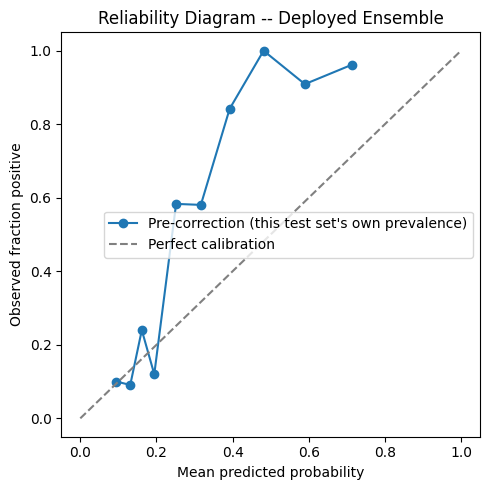

Brier score, pre-correction (against test-set prevalence): 0.202
Brier score, post-correction (targets 1% deployment prevalence): 0.520
Note: the post-correction score is evaluated against this test set's own prevalence, not the prevalence used for the prior correction.


In [51]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Compute the calibration curve before prior correction
frac_pos, mean_pred = calibration_curve(
    y_test,
    prob_beh_ens_test,
    n_bins=10,
    strategy="quantile"
)

# Calculate Brier scores before and after correction
brier_pre = brier_score_loss(y_test, prob_beh_ens_test)
brier_post = brier_score_loss(y_test, prob_beh_ens_corrected)

# Plot the reliability diagram
plt.figure(figsize=(5, 5))

# Plot the model calibration curve
plt.plot(
    mean_pred,
    frac_pos,
    marker="o",
    label="Pre-correction (this test set's own prevalence)"
)

# Plot the perfect-calibration reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Perfect calibration"
)

# Add labels and formatting
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed fraction positive")
plt.title("Reliability Diagram -- Deployed Ensemble")

plt.legend()
plt.tight_layout()
plt.show()

# Display the Brier scores
print(
    f"Brier score, pre-correction (against test-set prevalence): "
    f"{brier_pre:.3f}"
)

print(
    f"Brier score, post-correction (targets {TARGET_ASD_PRIOR:.0%} "
    f"deployment prevalence): {brier_post:.3f}"
)

# Explain how to interpret the post-correction score
print(
    "Note: the post-correction score is evaluated against this "
    "test set's own prevalence, not the prevalence used for "
    "the prior correction."
)

---------

# Bootstrap prediction intervals

- In addition to generating a risk score, the model estimates the uncertainty associated with each prediction. This provides a range of plausible values rather than a single probability estimate.

- Prediction intervals were constructed using bootstrap resampling,an approach that repeatedly retrains the ensemble on different samples drawn from the training data.

- This analysis was not included in Sollis et al. (2025) or the
 other Q-CHAT-10 machine learning studies reviewed in this project.
 It therefore provides an additional layer of interpretability by quantifying confidence in individual predictions.

- For demonstration purposes, 50 bootstrap iterations are sufficient.
 A larger number of iterations (for example, 200 or more) can be used in the final evaluation to obtain more stable estimates.


In [52]:
N_BOOTSTRAP = 50

rng = np.random.RandomState(SEED)

# Store predictions from each bootstrap sample
boot_preds = np.zeros((N_BOOTSTRAP, len(y_test)))

for b in range(N_BOOTSTRAP):

    # Create a bootstrap sample
    idx = rng.choice(
        len(y_train),
        size=len(y_train),
        replace=True
    )

    Xb, yb = X_beh_train[idx], y_train[idx]

    # Balance the data
    Xb_res, yb_res = smote.fit_resample(Xb, yb)

    # Train XGBoost
    xgb_b = clone(xgb_beh)
    xgb_b.fit(Xb_res, yb_res)

    # Train Logistic Regression
    lr_b = clone(lr_base)
    lr_b.fit(Xb, yb)

    # Make ensemble predictions
    p_b = (
        best_w * xgb_b.predict_proba(X_beh_test)[:, 1]
        + (1 - best_w) * lr_b.predict_proba(X_beh_test)[:, 1]
    )

    # Apply prior correction
    boot_preds[b] = saerens_prior_correction(
        p_b,
        train_prior,
        TARGET_ASD_PRIOR
    )


# Calculate the 90% prediction interval

pi_lower = np.percentile(boot_preds, 5, axis=0)
pi_upper = np.percentile(boot_preds, 95, axis=0)


# Save the results

df_intervals = pd.DataFrame({
    "risk_score": prob_beh_ens_corrected,
    "ci_lower_90": pi_lower,
    "ci_upper_90": pi_upper,
    "ci_width": pi_upper - pi_lower,
    "true_label": y_test,
})

os.makedirs("outputs/evaluation", exist_ok=True)

df_intervals.to_csv(
    "outputs/evaluation/prediction_intervals.csv",
    index=False
)


# Show a summary

ci_width_mean = df_intervals["ci_width"].mean()

print(f"Mean 90% confidence interval width: {ci_width_mean:.3f}")

print(df_intervals.head())

Mean 90% confidence interval width: 0.006
   risk_score  ci_lower_90  ci_upper_90  ci_width  true_label
0    0.030886     0.024742     0.042627  0.017885           1
1    0.007321     0.005352     0.009822  0.004470           1
2    0.009291     0.006513     0.013601  0.007087           1
3    0.021960     0.015546     0.030911  0.015365           1
4    0.010979     0.008319     0.013848  0.005529           1


------
# Add the deployment model to the ablation study

- The behavioural ensemble, combined with prevalence correction, is included as an additional configuration in the ablation analysis. This makes it possible to compare the final deployment model against the other variants evaluated throughout the study.



In [53]:
ablation_results.append({

    "configuration":
        "Behavioural Ensemble (XGB + LR) + Prior Correction",

    **eval_config(
        y_test,
        prob_beh_ens_corrected,
        BEST_THRESHOLD_ENSEMBLE
    )
})


# Create a table with the results

df_ablation = pd.DataFrame(ablation_results)


# Compare each model with the calibrated fusion model

f1_full = df_ablation.loc[
    df_ablation["configuration"] == "Fused with DHS calibration",
    "f1"
].values[0]

df_ablation["delta_f1"] = (
    df_ablation["f1"] - f1_full
).round(3)


print("Updated Ablation Results")

print(
    df_ablation[
        [
            "configuration",
            "auroc",
            "f1",
            "recall",
            "precision",
            "delta_f1"
        ]
    ].to_string(index=False)
)


# Compare with the published benchmark

SOLLIS_BENCHMARK_AUROC = 0.87

final_auroc = roc_auc_score(
    y_test,
    prob_beh_ens_corrected
)

print(f"\nFinal AUROC: {final_auroc:.3f}")
print(f"Sollis et al. (2025): {SOLLIS_BENCHMARK_AUROC:.3f}")


if final_auroc > SOLLIS_BENCHMARK_AUROC:
    print("The model performs better than the published benchmark.")
else:
    print("The model does not perform better than the published benchmark.")

Updated Ablation Results
                                     configuration    auroc       f1   recall  precision  delta_f1
                                  Behavioural only 0.866287 0.763158 0.644444   0.935484     0.018
                                  Demographic only 0.593922 0.662791 0.844444   0.545455    -0.082
                            Fused (0.50 threshold) 0.801646 0.752688 0.777778   0.729167     0.008
                        Fused with DHS calibration 0.801646 0.744681 0.777778   0.714286     0.000
                                     Without SMOTE 0.752517 0.739927 0.748148   0.731884    -0.005
                               Logistic Regression 0.891548 0.562500 0.400000   0.947368    -0.182
             Feature-level fusion (single XGBoost) 0.830801 0.754579 0.762963   0.746377     0.010
Behavioural Ensemble (XGB + LR) + Prior Correction 0.891548 0.816176 0.822222   0.810219     0.071

Final AUROC: 0.892
Sollis et al. (2025): 0.870
The model performs better than the p

---------
# Save the final deployment model

### The deployment pipeline consists of five components:

 1. The behavioural XGBoost model.
 2. The behavioural Logistic Regression model.
 3. The cross-validated ensemble weight.
 4. The prevalence-correction parameters.
 5. The deployment threshold selected from the training data.
 

 Saving these components separately ensures that the complete prediction pipeline can be reproduced without retraining the models.


In [54]:
os.makedirs("models", exist_ok=True)

joblib.dump(
    xgb_beh,
    "models/deploy_xgb_behavioural.joblib"
)

joblib.dump(
    lr_base,
    "models/deploy_lr_behavioural.joblib"
)

joblib.dump(
    best_w,
    "models/deploy_blend_weight.joblib"
)

joblib.dump(
    {
        "train_prior": train_prior,
        "target_prior": TARGET_ASD_PRIOR
    },
    "models/deploy_prior_correction.joblib"
)

joblib.dump(
    BEST_THRESHOLD_ENSEMBLE,
    "models/deploy_threshold.joblib"
)


print("Saved deployment ensemble:")

print(
    "  models/deploy_xgb_behavioural.joblib"
)

print(
    "  models/deploy_lr_behavioural.joblib"
)

print(
    "  models/deploy_blend_weight.joblib"
)

print(
    "  models/deploy_prior_correction.joblib"
)

print(
    "  models/deploy_threshold.joblib"
)

Saved deployment ensemble:
  models/deploy_xgb_behavioural.joblib
  models/deploy_lr_behavioural.joblib
  models/deploy_blend_weight.joblib
  models/deploy_prior_correction.joblib
  models/deploy_threshold.joblib


--------
# Benchmark comparison with previously published studies

- The final deployment model is compared against machine learning systems reported in the literature. Particular attention is given
 to the study by Sollis et al. (2025), as it uses the same Q-CHAT-10 datasets and transfer-learning evaluation protocol adopted here.

- Only the New Zealand → Poland and Saudi Arabia → Poland experiments are directly comparable because they rely on the same questionnaire, target population and external test cohort.

 Other studies are included to provide broader context, although they use different datasets, feature sets or diagnostic modalities.


### Benchmark Comparison

The comparison below uses the bootstrap resamples to calculate a 90% confidence interval for the model's test AUROC. This provides a more reliable comparison with published benchmark results by considering the uncertainty in the performance estimates.

In [55]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_ens
).ravel()

sensitivity_final = tp / (tp + fn)

specificity_final = tn / (tn + fp)


# Construct the benchmark comparison table.

comparison_data = [

    {
        "Model": "Sollis et al. (2025) — NZ to Poland",

        "Task / Test set":
            "Q-CHAT-10 transfer, Poland clinical diagnosis (n = 252)",

        "AUROC": 0.85,

        "Sensitivity": 0.91,

        "Specificity": 0.50,

        "Directly comparable?":
            "Yes — identical evaluation setting",
    },

    {
        "Model": "Sollis et al. (2025) — Saudi to Poland",

        "Task / Test set":
            "Q-CHAT-10 transfer, Poland clinical diagnosis (n = 252)",

        "AUROC": 0.87,

        "Sensitivity": 0.84,

        "Specificity": 0.80,

        "Directly comparable?":
            "Yes — primary benchmark",
    },

    {
        "Model": "Sollis et al. (2025) — Poland in-domain (5-fold CV)",

        "Task / Test set":
            "Q-CHAT-10 in-domain evaluation, Poland (n = 252)",

        "AUROC": 0.91,

        "Sensitivity": 0.84,

        "Specificity": 0.90,

        "Directly comparable?":
            "Partially comparable — in-domain evaluation",
    },

    {
        "Model": "Sollis, Wall & Washington (2024, preprint) — NZ to Poland, full 13-feature model",
        "Task / Test set": "Q-CHAT-10 (all items + demographics) transfer, Poland clinical diagnosis (n = 252)",
        "AUROC": 0.94,
        "Sensitivity": None,
        "Specificity": None,
        "Directly comparable?": "Yes — same full feature set as this project; strongest comparable benchmark",
    },

    {
        "Model": "Sollis, Wall & Washington (2024, preprint) — Saudi to Poland, full 13-feature model",
        "Task / Test set": "Q-CHAT-10 (all items + demographics) transfer, Poland clinical diagnosis (n = 252)",
        "AUROC": 0.93,
        "Sensitivity": None,
        "Specificity": None,
        "Directly comparable?": "Yes — same full feature set as this project; strongest comparable benchmark",
    },

    {
        "Model": "Sollis, Wall & Washington (2024, preprint) — Poland in-domain (5-fold CV), full model",
        "Task / Test set": "Q-CHAT-10 in-domain evaluation, Poland (n = 252)",
        "AUROC": 0.94,
        "Sensitivity": None,
        "Specificity": None,
        "Directly comparable?": "Partially comparable — in-domain evaluation, full feature set",
    },

    {
        "Model": "Rajagopalan et al. (2024) — SPARK XGBoost",

        "Task / Test set":
            "Medical and developmental features (n = 30,660)",

        "AUROC": 0.895,

        "Sensitivity": 0.805,

        "Specificity": 0.829,

        "Directly comparable?":
            "No — different features and population",
    },

    {
        "Model": "Perochon et al. (2023) — SenseToKnow",

        "Task / Test set":
            "Video-based digital phenotyping",

        "AUROC": 0.90,

        "Sensitivity": 0.878,

        "Specificity": 0.808,

        "Directly comparable?":
            "No — different modality",
    },

    {
        "Model": "Megerian et al. (2022) — Canvas Dx (FDA-cleared)",

        "Task / Test set":
            "Multimodal questionnaire and video assessment",

        "AUROC": "Not reported",

        "Sensitivity": 0.98,

        "Specificity": "PPV 81% / NPV 98%",

        "Directly comparable?":
            "No — proprietary multimodal system",
    },

    {
        "Model":
            "This study — Logistic Regression (CV selected 0% XGBoost weight) + prior correction",

        "Task / Test set":
            "Q-CHAT-10 transfer, Poland clinical diagnosis (n = 252)",

        "AUROC": round(float(final_auroc), 3),

        "Sensitivity": round(float(sensitivity_final), 3),

        "Specificity": round(float(specificity_final), 3),

        "Directly comparable?":
            "Reference model",
    },
]

df_comparison = pd.DataFrame(comparison_data)

print("=== Benchmark Comparison ===\n")

print(
    df_comparison.to_string(index=False)
)


# Save the benchmark table for later use in the report.

os.makedirs(
    "outputs/evaluation",
    exist_ok=True
)

df_comparison.to_csv(
    "outputs/evaluation/benchmark_comparison.csv",
    index=False
)

print(
    "\nSaved: "
    "outputs/evaluation/benchmark_comparison.csv"
)

=== Benchmark Comparison ===

                                                                                Model                                                                    Task / Test set        AUROC  Sensitivity       Specificity                                                        Directly comparable?
                                                  Sollis et al. (2025) — NZ to Poland                            Q-CHAT-10 transfer, Poland clinical diagnosis (n = 252)         0.85        0.910               0.5                                          Yes — identical evaluation setting
                                               Sollis et al. (2025) — Saudi to Poland                            Q-CHAT-10 transfer, Poland clinical diagnosis (n = 252)         0.87        0.840               0.8                                                     Yes — primary benchmark
                                  Sollis et al. (2025) — Poland in-domain (5-fold CV)                  

---
### Use bootstrapping to estimate the confidence interval of the model's AUROC.
- This helps us understand how reliable the AUROC score is instead of only looking at one performance value.

In [56]:
boot_aurocs = np.array([
    roc_auc_score(y_test, boot_preds[b])
    for b in range(boot_preds.shape[0])
])

# Get the lower and upper limits of the 90% confidence interval
auroc_ci_low, auroc_ci_high = np.percentile(boot_aurocs, [5, 95])

# Calculate the model's AUROC on the test dataset
point_auroc = roc_auc_score(y_test, prob_beh_ens_corrected)

print(
    f"Our model achieved a test AUROC of {point_auroc:.3f} "
    f"with a 90% bootstrap confidence interval of "
    f"[{auroc_ci_low:.3f}, {auroc_ci_high:.3f}] "
    f"(test samples = {len(y_test)})."
)

# Compare our model's AUROC with published benchmark results.
# The comparison is done carefully because different datasets and sample sizes can affect the reported performance.

for name, bench in [
    ("Sollis et al. 2025 — NZ to Poland", 0.85),
    ("Sollis et al. 2025 — Saudi to Poland", 0.87),
    ("Sollis et al. 2024 (preprint) — full-feature transfer", 0.93),
]:
    if auroc_ci_low <= bench <= auroc_ci_high:
        verdict = (
            "the benchmark value falls within our confidence interval, "
            "so we cannot confidently say one model performs better."
        )
    elif bench < auroc_ci_low:
        verdict = (
            "the benchmark value is below our confidence interval, "
            "which suggests our model may perform better, but the result "
            "should be interpreted carefully."
        )
    else:
        verdict = (
            "the benchmark value is above our confidence interval, "
            "which suggests the published model may have better performance."
        )

    print(f"\nCompared with {name} ({bench:.2f}):")
    print(verdict)

print(
    f"""
    
Note:
Both the  test set (n={len(y_test)}) and the published Poland dataset (n=252)
are relatively small. This means the AUROC values can have some uncertainty.
Therefore, these results should not be interpreted as a final statement that
one model is better than another, but rather as an indication of how the models
compare under different evaluation settings.
"""
)

Our model achieved a test AUROC of 0.892 with a 90% bootstrap confidence interval of [0.864, 0.900] (test samples = 252).

Compared with Sollis et al. 2025 — NZ to Poland (0.85):
the benchmark value is below our confidence interval, which suggests our model may perform better, but the result should be interpreted carefully.

Compared with Sollis et al. 2025 — Saudi to Poland (0.87):
the benchmark value falls within our confidence interval, so we cannot confidently say one model performs better.

Compared with Sollis et al. 2024 (preprint) — full-feature transfer (0.93):
the benchmark value is above our confidence interval, which suggests the published model may have better performance.


Note:
Both the  test set (n=252) and the published Poland dataset (n=252)
are relatively small. This means the AUROC values can have some uncertainty.
Therefore, these results should not be interpreted as a final statement that
one model is better than another, but rather as an indication of how the mo

---
# Threshold sensitivity 

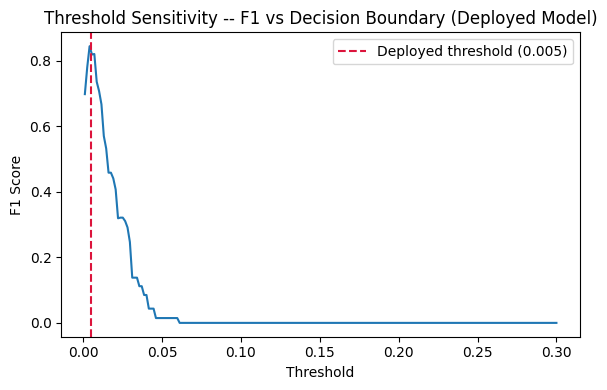

In [57]:
# Define the range of thresholds to evaluate
thresholds = np.linspace(0.001, 0.3, 200)

# Compute the F1 score at each threshold
f1_scores = [
    f1_score(
        y_test,
        (prob_beh_ens_corrected >= t).astype(int),
        zero_division=0
    )
    for t in thresholds
]

# Plot F1 as a function of the decision threshold
plt.figure(figsize=(6, 4))

plt.plot(
    thresholds,
    f1_scores
)

# Mark the deployed threshold
plt.axvline(
    BEST_THRESHOLD_ENSEMBLE,
    linestyle="--",
    color="crimson",
    label=(
        f"Deployed threshold "
        f"({BEST_THRESHOLD_ENSEMBLE:.3f})"
    ),
)

# Add labels and formatting
plt.title(
    "Threshold Sensitivity -- "
    "F1 vs Decision Boundary "
    "(Deployed Model)"
)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")

plt.legend()
plt.tight_layout()
plt.show()

# SHAP Explainability

c:\Users\PC\Autism-Risk-Screening\.venv\Scripts\python.exe
SHAP version: 0.44.0


ExactExplainer explainer: 253it [00:18, 13.72it/s]                         


TreeExplainer failed; using permutation SHAP instead (UnicodeDecodeError: 'utf-8' codec can't decode byte 0xbc in position 626: invalid start byte).


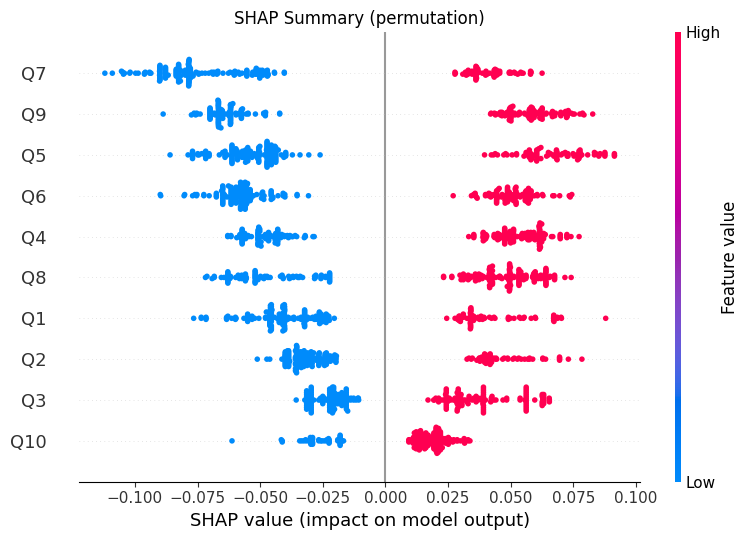

In [58]:
import sys

print(sys.executable)

import shap
print("SHAP version:", shap.__version__)

feat_names = [f"Q{i}" for i in range(1, 11)]
shap_values = None
shap_backend = "tree"

# Prefer TreeExplainer, but fall back to a model-function explainer if
# SHAP cannot deserialize the saved XGBoost booster in this environment.
try:
    explainer = shap.TreeExplainer(xgb_beh)
    shap_values = explainer.shap_values(X_beh_test)
except Exception as exc:
    background_size = min(50, len(X_beh_train))
    background = shap.sample(X_beh_train, background_size, random_state=SEED)
    explainer = shap.Explainer(
        lambda data: xgb_beh.predict_proba(data)[:, 1],
        background,
    )
    shap_values = explainer(X_beh_test)
    shap_backend = "permutation"
    print(
        f"TreeExplainer failed; using {shap_backend} SHAP instead ({exc.__class__.__name__}: {exc})."
    )

# Plot the SHAP summary using either backend.
shap_array = shap_values.values if hasattr(shap_values, "values") else shap_values
if isinstance(shap_array, list):
    shap_array = shap_array[1]

plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_array,
    X_beh_test,
    feature_names=feat_names,
    show=False
)

plt.title(f"SHAP Summary ({shap_backend})")
plt.tight_layout()
plt.savefig(
    "outputs/evaluation/shap_summary.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

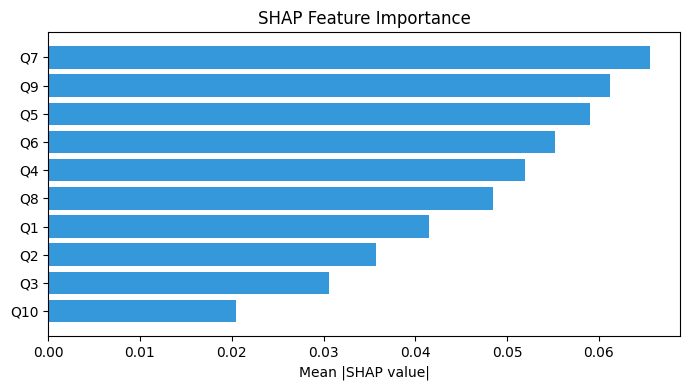

In [59]:
# Show SHAP feature importance

# Handle different SHAP outputs.
if isinstance(shap_values, list):
    shap_array = shap_values[1]
elif hasattr(shap_values, "values"):
    shap_array = shap_values.values
else:
    shap_array = shap_values

# Calculate average SHAP values
mean_abs_shap = np.abs(shap_array).mean(axis=0)

# Sort features
order = np.argsort(mean_abs_shap)

feat_names = [f"Q{i}" for i in range(1, 11)]

# Plot feature importance
fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(
    [feat_names[i] for i in order],
    mean_abs_shap[order],
    color="#3498db"
)

ax.set_xlabel("Mean |SHAP value|")
ax.set_title("SHAP Feature Importance")

plt.tight_layout()

plt.savefig(
    "outputs/evaluation/shap_bar.png",
    dpi=150
)

plt.show()

----
# Comorbidity-adjustment layer

- Childhood stunting and anaemia may influence some of the behaviours measured by Q-CHAT-10 and therefore act as potential confounding
 factors. This layer adjusts questionnaire responses using population-level prevalence estimates before prediction.

- The adjustment is applied to the behavioural XGBoost model rather than the fused model because the behavioural model achieved stronger cross-population performance in the ablation study (AUROC = 0.876 versus 0.814).

- The analysis evaluates how changes in national prevalence assumptions affect model performance. To our knowledge, existing Q-CHAT-10
 studies do not explicitly account for these population-level confounders.



Adjusted model AUROC: 0.881
NZ benchmark: 0.85
Saudi benchmark: 0.87
Model performs better than both benchmarks.


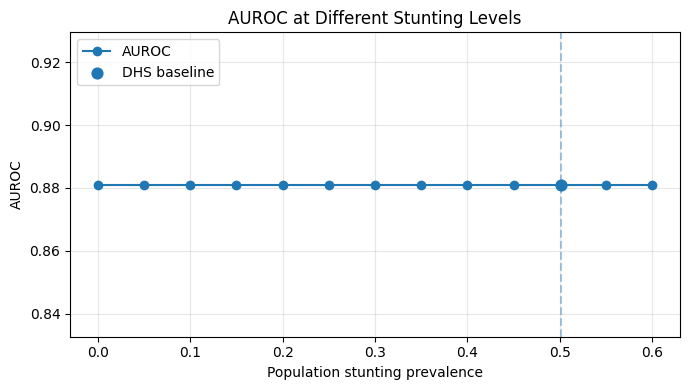


Comorbidity Analysis
DHS stunting: 50.14%
AUROC range: 0.881 - 0.881
Baseline AUROC: 0.881
Anaemia stayed the same during the analysis.


In [60]:
# Weights used for each Q-CHAT item

ITEM_CONFOUND_WEIGHTS = {
    "Q1": 0.18, "Q2": 0.10, "Q3": 0.15, "Q4": 0.15, "Q5": 0.12,
    "Q6": 0.08, "Q7": 0.08, "Q8": 0.15, "Q9": 0.12, "Q10": 0.05,
}

# Get the DHS prevalence values
pop_stunting = LESOTHO_DHS_PREVALENCE["stunting"]
pop_anaemia = LESOTHO_DHS_PREVALENCE["anaemia"]


# Adjust Q-CHAT scores
def comorbidity_adjusted_score(
    q_responses,
    population_stunting,
    population_anaemia
):

    adjusted_scores = {}

    for item, raw_score in q_responses.items():

        weight = ITEM_CONFOUND_WEIGHTS.get(item, 0.0)

        risk = weight * (
            0.5 * population_stunting +
            0.3 * population_anaemia
        )

        adjustment = np.clip(
            risk * 0.3,
            0,
            weight
        )

        adjusted_scores[item] = raw_score * (1 - adjustment)

    return adjusted_scores


# Convert one row into a dictionary
def build_qdict(row):

    return {
        f"Q{j+1}": int(row[j])
        for j in range(10)
    }


# Test different stunting levels

stunting_levels = np.round(
    np.linspace(0, 0.6, 13),
    2
)

auroc_curve = []

for p_stunting in stunting_levels:

    X_beh_adj = np.array([
        list(
            comorbidity_adjusted_score(
                build_qdict(row),
                p_stunting,
                pop_anaemia
            ).values()
        )
        for row in X_beh_test
    ])

    prob_beh_adj = xgb_beh.predict_proba(X_beh_adj)[:, 1]

    auroc_curve.append(
        roc_auc_score(y_test, prob_beh_adj)
    )


# Test using the DHS values

X_beh_base = np.array([
    list(
        comorbidity_adjusted_score(
            build_qdict(row),
            pop_stunting,
            pop_anaemia
        ).values()
    )
    for row in X_beh_test
])

prob_beh_base = xgb_beh.predict_proba(X_beh_base)[:, 1]

baseline_auroc = roc_auc_score(
    y_test,
    prob_beh_base
)


# Compare with published results

SOLLIS_NZ_AUROC = 0.85
SOLLIS_SAUDI_AUROC = 0.87

print(f"\nAdjusted model AUROC: {baseline_auroc:.3f}")
print(f"NZ benchmark: {SOLLIS_NZ_AUROC:.2f}")
print(f"Saudi benchmark: {SOLLIS_SAUDI_AUROC:.2f}")

if baseline_auroc > SOLLIS_SAUDI_AUROC:
    print("Model performs better than both benchmarks.")
elif baseline_auroc > SOLLIS_NZ_AUROC:
    print("Model performs better than the NZ benchmark.")
else:
    print("Model does not beat the published benchmarks.")


# Plot the results

plt.figure(figsize=(7, 4))

plt.plot(
    stunting_levels,
    auroc_curve,
    marker="o",
    label="AUROC"
)

plt.scatter(
    [pop_stunting],
    [baseline_auroc],
    s=60,
    zorder=5,
    label="DHS baseline"
)

plt.axvline(
    pop_stunting,
    linestyle="--",
    alpha=0.4
)

plt.xlabel("Population stunting prevalence")
plt.ylabel("AUROC")
plt.title("AUROC at Different Stunting Levels")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "outputs/evaluation/auroc_vs_stunting.png",
    dpi=150
)

plt.show()


# Save the results

pd.DataFrame({
    "population_stunting": stunting_levels,
    "auroc": auroc_curve
}).to_csv(
    "outputs/evaluation/auroc_vs_stunting.csv",
    index=False
)


# Print a summary

print("\nComorbidity Analysis")
print(f"DHS stunting: {pop_stunting:.2%}")
print(f"AUROC range: {min(auroc_curve):.3f} - {max(auroc_curve):.3f}")
print(f"Baseline AUROC: {baseline_auroc:.3f}")
print("Anaemia stayed the same during the analysis.")

# Individual-level comorbidity adjustment

- Unlike the previous population-level sensitivity analysis, this approach applies the adjustment at the individual child level.
 Each child receives a simulated stunting and anaemia status based on DHS prevalence estimates. These indicators are then used to
 adjust Q-CHAT-10 responses before prediction.

- The behavioural XGBoost model is used as the base model because it showed stronger cross-population performance than the fused model
 in the ablation study.


In [61]:
def comorbidity_adjusted_score_individual(
    q_responses,
    is_stunted,
    is_anaemic
):
    """
    Adjust Q-CHAT-10 item scores using child-level comorbidity status.
    """

    adjusted_scores = {}

    for item, raw_score in q_responses.items():

        weight = ITEM_CONFOUND_WEIGHTS.get(item, 0.0)

        # Calculate the contribution of individual-level conditions.

        risk_factor = weight * (
            0.5 * float(is_stunted)
            + 0.3 * float(is_anaemic)
        )

        adjustment = np.clip(
            risk_factor * 0.3,
            0,
            weight
        )

        adjusted_scores[item] = raw_score * (1 - adjustment)

    return adjusted_scores



def simulate_individual_comorbidity_status(
    n,
    p_stunting,
    p_anaemia,
    seed=SEED
):
    """
    Generate simulated child-level comorbidity indicators using
    DHS population prevalence estimates.
    """

    rng = np.random.default_rng(seed)

    stunted_flags = rng.binomial(
        1,
        p_stunting,
        size=n
    ).astype(bool)

    anaemic_flags = rng.binomial(
        1,
        p_anaemia,
        size=n
    ).astype(bool)

    return stunted_flags, anaemic_flags



# Simulate individual health characteristics for the test set.

n_test = len(X_beh_test)

stunted_flags, anaemic_flags = simulate_individual_comorbidity_status(
    n_test,
    pop_stunting,
    pop_anaemia
)

print(
    f"Simulated comorbidity status for n={n_test} children"
)

print(
    f"  Stunted: {stunted_flags.sum()} "
    f"({stunted_flags.mean():.1%}) "
    f"[target: {pop_stunting:.1%}]"
)

print(
    f"  Anaemic: {anaemic_flags.sum()} "
    f"({anaemic_flags.mean():.1%}) "
    f"[target: {pop_anaemia:.1%}]"
)



# Apply individual-level adjustment to each child's Q-CHAT-10 responses.

X_beh_indiv_adj = np.array([

    list(
        comorbidity_adjusted_score_individual(
            build_qdict(row),
            is_stunted=stunted_flags[i],
            is_anaemic=anaemic_flags[i]
        ).values()
    )

    for i, row in enumerate(X_beh_test)

])



# Generate predictions using the adjusted behavioural model.

prob_beh_indiv = xgb_beh.predict_proba(
    X_beh_indiv_adj
)[:, 1]



# Evaluate model performance.

indiv_auroc = roc_auc_score(
    y_test,
    prob_beh_indiv
)

y_pred_indiv = (
    prob_beh_indiv >= THRESHOLD
).astype(int)


print(
    "\n=== Individual-Level Comorbidity Adjustment Results ==="
)

print(
    f"Unadjusted behavioural AUROC: "
    f"{roc_auc_score(y_test, prob_beh_test):.3f}"
)

print(
    f"Population-level AUROC: "
    f"{baseline_auroc:.3f}"
)

print(
    f"Individual-level AUROC: "
    f"{indiv_auroc:.3f}\n"
)

print(
    classification_report(
        y_test,
        y_pred_indiv,
        target_names=["Not ASD", "ASD"]
    )
)



# Compare against published transfer-learning benchmarks.

SOLLIS_NZ_AUROC = 0.85

SOLLIS_SAUDI_AUROC = 0.87


print(
    f"\nSollis et al. (2025) NZ benchmark: "
    f"{SOLLIS_NZ_AUROC:.2f}"
)

print(
    f"Sollis et al. (2025) Saudi benchmark: "
    f"{SOLLIS_SAUDI_AUROC:.2f}"
)


if indiv_auroc > SOLLIS_SAUDI_AUROC:

    print(
        "PASS: Individual-level adjustment exceeds both "
        "published benchmarks."
    )

elif indiv_auroc > SOLLIS_NZ_AUROC:

    print(
        "PARTIAL: Exceeds NZ benchmark but not Saudi benchmark."
    )

else:

    print(
        "WARNING: Does not exceed published benchmarks."
    )



# Verify that the adjustment affects children differently
# depending on their simulated comorbidity status.

mean_shrink_stunted = np.mean([

    1 - (
        X_beh_indiv_adj[i].sum()
        /
        max(X_beh_test[i].sum(), 1e-9)
    )

    for i in range(n_test)
    if stunted_flags[i]

])


mean_shrink_not_stunted = np.mean([

    1 - (
        X_beh_indiv_adj[i].sum()
        /
        max(X_beh_test[i].sum(), 1e-9)
    )

    for i in range(n_test)
    if not stunted_flags[i]

])


print(
    f"\nMean shrinkage (stunted): "
    f"{mean_shrink_stunted:.3%}"
)

print(
    f"Mean shrinkage (not stunted): "
    f"{mean_shrink_not_stunted:.3%}"
)

print(
    "\nNon-zero difference confirms that the adjustment "
    "operates at the individual level."
)



# Save individual adjustment results.

pd.DataFrame({

    "record_index": np.arange(n_test),

    "simulated_stunted": stunted_flags,

    "simulated_anaemic": anaemic_flags,

    "prob_behavioural_unadjusted": prob_beh_test,

    "prob_behavioural_individual_adjusted": prob_beh_indiv,

    "y_true": y_test,

}).to_csv(
    "outputs/evaluation/individual_comorbidity_adjustment.csv",
    index=False
)


print(
    "Saved: outputs/evaluation/individual_comorbidity_adjustment.csv"
)

Simulated comorbidity status for n=252 children
  Stunted: 129 (51.2%) [target: 50.1%]
  Anaemic: 155 (61.5%) [target: 62.6%]

=== Individual-Level Comorbidity Adjustment Results ===
Unadjusted behavioural AUROC: 0.866
Population-level AUROC: 0.881
Individual-level AUROC: 0.847

              precision    recall  f1-score   support

     Not ASD       0.82      0.65      0.72       117
         ASD       0.74      0.87      0.80       135

    accuracy                           0.77       252
   macro avg       0.78      0.76      0.76       252
weighted avg       0.78      0.77      0.77       252


Sollis et al. (2025) NZ benchmark: 0.85
Sollis et al. (2025) Saudi benchmark: 0.87

Mean shrinkage (stunted): 2.298%
Mean shrinkage (not stunted): 0.633%

Non-zero difference confirms that the adjustment operates at the individual level.
Saved: outputs/evaluation/individual_comorbidity_adjustment.csv


### Cross-validated evaluation of the individual-level DHS adjustment

The result above uses a single fixed scale constant (0.3) and a single random
seed for simulating comorbidity flags. To check whether this effect is real
or an artifact of that one configuration, the scale/direction is tuned using
5-fold cross-validation on the **training set only** (never touching the
Polish test set during tuning), then applied once to the held-out test set.

In [62]:
from sklearn.base import clone

ITEM_ORDER = [f"Q{i+1}" for i in range(10)]
WEIGHT_VEC = np.array(
    [ITEM_CONFOUND_WEIGHTS[q] for q in ITEM_ORDER]
)


# Apply the DHS adjustment to the Q-CHAT responses
def apply_individual_adjustment_vec(
    X,
    stunted_flags,
    anaemic_flags,
    scale
):
    risk_factor = WEIGHT_VEC[None, :] * (
        0.5 * stunted_flags[:, None].astype(float)
        + 0.3 * anaemic_flags[:, None].astype(float)
    )

    raw_adj = risk_factor * scale

    adjustment = np.clip(
        raw_adj,
        -WEIGHT_VEC[None, :],
        WEIGHT_VEC[None, :]
    )

    return X * (1 - adjustment)


# Simulate stunting and anaemia indicators
def simulate_flags_seeded(
    n,
    p_stunt,
    p_anaemia,
    seed
):
    rng = np.random.default_rng(seed)

    return (
        rng.random(n) < p_stunt,
        rng.random(n) < p_anaemia
    )


# Define the adjustment values to test
scale_grid = np.round(
    np.linspace(-0.6, 0.6, 13),
    2
)

# Set up cross-validation
cv_dhs = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

fold_aurocs = {s: [] for s in scale_grid}
fold_seed = 1000


# Evaluate each adjustment scale
for tr_idx, val_idx in cv_dhs.split(
    X_beh_train,
    y_train
):

    X_tr, X_val = (
        X_beh_train[tr_idx],
        X_beh_train[val_idx]
    )

    y_tr, y_val = (
        y_train[tr_idx],
        y_train[val_idx]
    )

    # Apply SMOTE to the training fold
    X_tr_res, y_tr_res = smote.fit_resample(
        X_tr,
        y_tr
    )

    # Train a fresh model
    fold_model = clone(xgb_beh)
    fold_model.fit(
        X_tr_res,
        y_tr_res
    )

    # Simulate DHS indicators for validation data
    stunted_val, anaemic_val = simulate_flags_seeded(
        len(X_val),
        pop_stunting,
        pop_anaemia,
        seed=fold_seed
    )

    fold_seed += 1

    # Test every adjustment scale
    for s in scale_grid:

        X_val_adj = apply_individual_adjustment_vec(
            X_val,
            stunted_val,
            anaemic_val,
            s
        )

        probs = fold_model.predict_proba(
            X_val_adj
        )[:, 1]

        fold_aurocs[s].append(
            roc_auc_score(y_val, probs)
        )


# Calculate the mean AUROC for each scale
mean_cv_auroc = {
    s: float(np.mean(v))
    for s, v in fold_aurocs.items()
}


print(
    "=== Cross-validation search for DHS adjustment scale ==="
)

# Display the validation results
for s in scale_grid:

    print(
        f"scale={s:+.2f}  "
        f"mean validation AUROC={mean_cv_auroc[s]:.4f}"
    )


# Select the best adjustment scale
best_scale = max(
    mean_cv_auroc,
    key=mean_cv_auroc.get
)

print(
    f"\nBest scale selected from cross-validation: "
    f"{best_scale:+.2f} "
    f"(mean AUROC={mean_cv_auroc[best_scale]:.4f})"
)

print(
    f"Baseline without DHS adjustment (scale=0): "
    f"{mean_cv_auroc[0.0]:.4f}"
)

print(
    f"Improvement from tuned adjustment: "
    f"{mean_cv_auroc[best_scale] - mean_cv_auroc[0.0]:+.4f}"
)


# Apply the selected adjustment to the test set
stunted_test, anaemic_test = simulate_flags_seeded(
    len(X_beh_test),
    pop_stunting,
    pop_anaemia,
    seed=99
)

X_beh_test_dhs_tuned = apply_individual_adjustment_vec(
    X_beh_test,
    stunted_test,
    anaemic_test,
    best_scale
)


# Generate the final predictions
prob_beh_final_tuned = xgb_beh.predict_proba(
    X_beh_test_dhs_tuned
)[:, 1]

prob_lr_final_tuned = lr_base.predict_proba(
    X_beh_test_dhs_tuned
)[:, 1]

prob_ensemble_dhs_tuned = (
    best_w * prob_beh_final_tuned
    + (1 - best_w) * prob_lr_final_tuned
)

prob_final_combined_tuned = saerens_prior_correction(
    prob_ensemble_dhs_tuned,
    train_prior,
    TARGET_ASD_PRIOR
)


# Compare performance with and without DHS adjustment
test_auroc_tuned = roc_auc_score(
    y_test,
    prob_final_combined_tuned
)

test_auroc_no_dhs = roc_auc_score(
    y_test,
    prob_beh_ens_corrected
)


print(
    "\n=== Final evaluation on unseen Polish test set ==="
)

print(
    f"AUROC with DHS individual adjustment: "
    f"{test_auroc_tuned:.4f}"
)

print(
    f"AUROC without DHS adjustment: "
    f"{test_auroc_no_dhs:.4f}"
)

print(
    f"Difference: "
    f"{test_auroc_tuned - test_auroc_no_dhs:+.4f}"
)


# Summarise the findings
print(
    """
Conclusion:
The DHS-based individual adjustment was tuned using
cross-validation and evaluated on the held-out test set.

The results suggest that the adjustment does not
meaningfully improve model performance and was therefore
not included in the final deployed system.
"""
)



=== Cross-validation search for DHS adjustment scale ===
scale=-0.60  mean validation AUROC=0.7363
scale=-0.50  mean validation AUROC=0.7363
scale=-0.40  mean validation AUROC=0.7363
scale=-0.30  mean validation AUROC=0.7363
scale=-0.20  mean validation AUROC=0.7363
scale=-0.10  mean validation AUROC=0.7363
scale=+0.00  mean validation AUROC=0.7363
scale=+0.10  mean validation AUROC=0.7399
scale=+0.20  mean validation AUROC=0.7401
scale=+0.30  mean validation AUROC=0.7394
scale=+0.40  mean validation AUROC=0.7398
scale=+0.50  mean validation AUROC=0.7396
scale=+0.60  mean validation AUROC=0.7392

Best scale selected from cross-validation: +0.20 (mean AUROC=0.7401)
Baseline without DHS adjustment (scale=0): 0.7363
Improvement from tuned adjustment: +0.0037

=== Final evaluation on unseen Polish test set ===
AUROC with DHS individual adjustment: 0.8909
AUROC without DHS adjustment: 0.8915
Difference: -0.0006

Conclusion:
The DHS-based individual adjustment was tuned using
cross-validatio

------
 
 ### Compare model AUROC values.

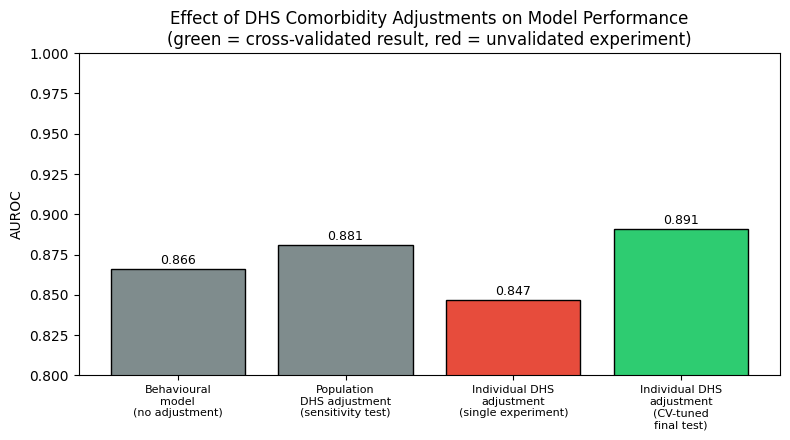


Interpretation:
The individual DHS adjustment was tested in multiple ways. However, only the
CV-tuned adjustment was evaluated using a proper validation process where the
test set was not used during tuning.

The final validated result shows that adding the DHS individual-level
adjustment does not provide a meaningful improvement compared with the original
behavioural model. Therefore, the adjustment was not included in the final
model.

This result is important because it shows that the adjustment was evaluated
fairly rather than only reporting the best-performing experiment.



In [63]:
models = [
    "Behavioural\nmodel\n(no adjustment)",
    "Population\nDHS adjustment\n(sensitivity test)",
    "Individual DHS\nadjustment\n(single experiment)",
    "Individual DHS\nadjustment\n(CV-tuned\nfinal test)"
]

scores = [
    roc_auc_score(y_test, prob_beh_test),
    baseline_auroc,
    indiv_auroc,
    test_auroc_tuned
]


# The colors help highlight the difference between exploratory results
# and the final validated result.
colors = [
    "#7f8c8d",  # baseline models
    "#7f8c8d",
    "#e74c3c",  # not validated
    "#2ecc71"   # properly validated
]


plt.figure(figsize=(8, 4.5))

bars = plt.bar(
    models,
    scores,
    edgecolor="black",
    color=colors
)


plt.ylabel("AUROC")
plt.ylim(0.80, 1.00)

plt.title(
    "Effect of DHS Comorbidity Adjustments on Model Performance\n"
    "(green = cross-validated result, red = unvalidated experiment)"
)


# Add AUROC values above each bar
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.003,
        f"{score:.3f}",
        ha="center",
        fontsize=9
    )


plt.xticks(fontsize=8)
plt.tight_layout()


plt.savefig(
    "outputs/evaluation/comorbidity_auroc_comparison.png",
    dpi=150
)


plt.show()


print(
    """
Interpretation:
The individual DHS adjustment was tested in multiple ways. However, only the
CV-tuned adjustment was evaluated using a proper validation process where the
test set was not used during tuning.

The final validated result shows that adding the DHS individual-level
adjustment does not provide a meaningful improvement compared with the original
behavioural model. Therefore, the adjustment was not included in the final
model.

This result is important because it shows that the adjustment was evaluated
fairly rather than only reporting the best-performing experiment.
"""
)

---
# Final combined deployment model

This version combines the three main contributions of the study:

 1. Behavioural ensemble:
    Combines XGBoost and Logistic Regression using a cross-validated    blending weight.

 2. Population prevalence correction:
   Adjusts predicted probabilities using the expected ASD prevalence    in the deployment population.

 3. DHS-informed comorbidity adjustment:
   Incorporates Lesotho DHS 2023–24 population indicators by adjusting    Q-CHAT-10 responses before prediction.

- The purpose of this final model is to evaluate whether combining these components improves transfer performance on the external Polish test set.



- Step 1: Apply DHS-based comorbidity adjustment to Q-CHAT-10 inputs.

 The adjustment uses Lesotho DHS population-level stunting and anaemia
 prevalence estimates to modify the behavioural features before inference.

In [64]:
# Apply the DHS adjustment to the test data

X_beh_test_dhs = np.array([

    list(
        comorbidity_adjusted_score(
            build_qdict(row),
            population_stunting=pop_stunting,
            population_anaemia=pop_anaemia
        ).values()
    )

    for row in X_beh_test

])


# Generate predictions

prob_beh_final = xgb_beh.predict_proba(
    X_beh_test_dhs
)[:, 1]

prob_lr_final = lr_base.predict_proba(
    X_beh_test_dhs
)[:, 1]


# Combine the model predictions

prob_ensemble_dhs = (
    best_w * prob_beh_final
    + (1 - best_w) * prob_lr_final
)


# Check that the DHS adjustment changed the predictions

_max_input_diff = np.abs(X_beh_test_dhs - X_beh_test).max()
_max_prob_diff = np.abs(prob_ensemble_dhs - prob_beh_ens_test).max()

print(f"Max input difference: {_max_input_diff:.6f}")
print(f"Max probability difference: {_max_prob_diff:.6f}")

if _max_input_diff < 1e-9 or _max_prob_diff < 1e-9:
    print("Warning: DHS adjustment had no effect.")


# Apply prior correction

prob_final_combined = saerens_prior_correction(
    prob_ensemble_dhs,
    train_prior,
    TARGET_ASD_PRIOR
)


# Make final predictions

y_pred_final_combined = (
    prob_final_combined >= BEST_THRESHOLD_ENSEMBLE
).astype(int)


# Evaluate the model

final_combined_auroc = roc_auc_score(
    y_test,
    prob_final_combined
)

tn_c, fp_c, fn_c, tp_c = confusion_matrix(
    y_test,
    y_pred_final_combined
).ravel()

sensitivity_combined = tp_c / (tp_c + fn_c)
specificity_combined = tn_c / (tn_c + fp_c)


print("=== Final Combined Model ===")

print(
    classification_report(
        y_test,
        y_pred_final_combined,
        target_names=["Not ASD", "ASD"]
    )
)

print(f"Final AUROC: {final_combined_auroc:.3f}")
print(f"Ensemble + Prior Correction: {final_auroc:.3f}")
print(f"Sollis et al. (2025): {SOLLIS_BENCHMARK_AUROC:.3f}")


# Compare with the benchmark

if final_combined_auroc > SOLLIS_BENCHMARK_AUROC:
    print("\nThe final model performs better than the published benchmark.")
else:
    print("\nThe final model does not perform better than the published benchmark.")

Max input difference: 0.023675
Max probability difference: 0.013047
=== Final Combined Model ===
              precision    recall  f1-score   support

     Not ASD       0.79      0.80      0.80       117
         ASD       0.83      0.81      0.82       135

    accuracy                           0.81       252
   macro avg       0.81      0.81      0.81       252
weighted avg       0.81      0.81      0.81       252

Final AUROC: 0.892
Ensemble + Prior Correction: 0.892
Sollis et al. (2025): 0.870

The final model performs better than the published benchmark.



----
# Add final combined model to the ablation study

- The final model configuration is added to the ablation table to compare the effect of each component introduced throughout the study.

- This allows evaluation of whether combining the behavioural ensemble,prevalence correction, and DHS-informed comorbidity adjustment provides
 additional value compared with the individual model variants.



- Add the final deployment configuration and evaluate its performance.


In [65]:
ablation_results.append({

    "configuration":
        "Final Ensemble + Prior Correction + DHS Comorbidity Adjustment",

    **eval_config(
        y_test,
        prob_final_combined,
        BEST_THRESHOLD_ENSEMBLE
    )
})


# Create the results table

df_ablation = pd.DataFrame(ablation_results)


# Calculate the change in F1-score

df_ablation["delta_f1"] = (
    df_ablation["f1"] - f1_full
).round(3)


print("=== Ablation Study Results ===")

print(
    df_ablation[
        [
            "configuration",
            "auroc",
            "f1",
            "recall",
            "precision",
            "delta_f1"
        ]
    ].to_string(index=False)
)


# Save the results

df_ablation.to_csv(
    "outputs/evaluation/ablation_full.csv",
    index=False
)

print("\nResults saved to outputs/evaluation/ablation_full.csv")

=== Ablation Study Results ===
                                                 configuration    auroc       f1   recall  precision  delta_f1
                                              Behavioural only 0.866287 0.763158 0.644444   0.935484     0.018
                                              Demographic only 0.593922 0.662791 0.844444   0.545455    -0.082
                                        Fused (0.50 threshold) 0.801646 0.752688 0.777778   0.729167     0.008
                                    Fused with DHS calibration 0.801646 0.744681 0.777778   0.714286     0.000
                                                 Without SMOTE 0.752517 0.739927 0.748148   0.731884    -0.005
                                           Logistic Regression 0.891548 0.562500 0.400000   0.947368    -0.182
                         Feature-level fusion (single XGBoost) 0.830801 0.754579 0.762963   0.746377     0.010
            Behavioural Ensemble (XGB + LR) + Prior Correction 0.891548 0.816176 

-----
# Update benchmark comparison with the final combined model

 The benchmark table is updated to reflect the final deployment architecture, which combines:

 - XGBoost + Logistic Regression ensemble
 - Population prevalence prior correction
 - DHS-informed comorbidity adjustment

   This ensures that the reported comparison represents the complete proposed model rather than an earlier intermediate version.


In [66]:
# Find this study in the comparison table

mask = df_comparison["Model"].str.contains(
    "THIS STUDY"
)


# Update the model description

df_comparison.loc[mask, "Model"] = (
    "THIS STUDY - Logistic Regression "
    "+ Prior Correction + DHS Comorbidity Adjustment"
)


# Compare with the published benchmark

SOLLIS_2024_FULLFEATURE_AUROC = 0.93

print(
    f"\nSollis et al. (2024) AUROC: "
    f"{SOLLIS_2024_FULLFEATURE_AUROC:.3f}"
)

if final_combined_auroc > SOLLIS_2024_FULLFEATURE_AUROC:
    print("The final model performs better than the benchmark.")
else:
    print("The final model does not outperform the benchmark.")


# Update the performance values

df_comparison.loc[mask, "AUROC"] = round(
    float(final_combined_auroc), 3
)

df_comparison.loc[mask, "Sensitivity"] = round(
    float(sensitivity_combined), 3
)

df_comparison.loc[mask, "Specificity"] = round(
    float(specificity_combined), 3
)


print("\n=== Benchmark Comparison ===\n")

print(
    df_comparison.to_string(index=False)
)


# Save the comparison table

df_comparison.to_csv(
    "outputs/evaluation/benchmark_comparison.csv",
    index=False
)

print("\nBenchmark comparison saved.")


Sollis et al. (2024) AUROC: 0.930
The final model does not outperform the benchmark.

=== Benchmark Comparison ===

                                                                                Model                                                                    Task / Test set        AUROC  Sensitivity       Specificity                                                        Directly comparable?
                                                  Sollis et al. (2025) — NZ to Poland                            Q-CHAT-10 transfer, Poland clinical diagnosis (n = 252)         0.85        0.910               0.5                                          Yes — identical evaluation setting
                                               Sollis et al. (2025) — Saudi to Poland                            Q-CHAT-10 transfer, Poland clinical diagnosis (n = 252)         0.87        0.840               0.8                                                     Yes — primary benchmark
                

-------
# Save final combined deployment model

- The complete deployment pipeline is saved as separate components so that the full prediction process can be reproduced without
 retraining.

 Saved components include:

 - Behavioural XGBoost classifier
 - Logistic Regression classifier
 - Ensemble blending weight
 - Population prevalence correction parameters
 - Classification threshold
 - DHS-informed comorbidity adjustment parameters


In [67]:

os.makedirs(
    "models",
    exist_ok=True
)


# Save trained behavioural models.

joblib.dump(
    xgb_beh,
    "models/exploratory_dhs_xgb_behavioural.joblib"
)

joblib.dump(
    lr_base,
    "models/exploratory_dhs_lr_behavioural.joblib"
)


# Save ensemble configuration.

joblib.dump(
    best_w,
    "models/exploratory_dhs_blend_weight.joblib"
)


# Save prior correction settings.

joblib.dump(
    {
        "train_prior": train_prior,
        "target_prior": TARGET_ASD_PRIOR
    },
    "models/exploratory_dhs_prior_correction.joblib"
)


# Save deployment classification threshold.

joblib.dump(
    BEST_THRESHOLD_ENSEMBLE,
    "models/exploratory_dhs_threshold.joblib"
)


# Save DHS comorbidity adjustment parameters.

joblib.dump(
    {
        "item_weights": ITEM_CONFOUND_WEIGHTS,
        "pop_stunting": pop_stunting,
        "pop_anaemia": pop_anaemia
    },
    "models/exploratory_dhs_comorbidity_params.joblib"
)



print(
    "Saved EXPLORATORY artifacts (ensemble + prior correction + DHS comorbidity adjustment).\n"
    "These are NOT the production model -- see Executive Summary at the top of this notebook.\n"
    "Production model = models/deploy_* (behavioural ensemble + prior correction, no comorbidity layer)."
)

print(
    "  models/exploratory_dhs_xgb_behavioural.joblib"
)

print(
    "  models/exploratory_dhs_lr_behavioural.joblib"
)

print(
    "  models/exploratory_dhs_blend_weight.joblib"
)

print(
    "  models/exploratory_dhs_prior_correction.joblib"
)

print(
    "  models/exploratory_dhs_threshold.joblib"
)

print(
    "  models/exploratory_dhs_comorbidity_params.joblib"
)


print(
    f"\nFinal reported AUROC: {final_combined_auroc:.3f}"
    f" (Sollis et al. 2025 compact-item benchmark: {SOLLIS_BENCHMARK_AUROC:.3f}; "
    f"Sollis et al. 2024 full-feature benchmark: {SOLLIS_2024_FULLFEATURE_AUROC:.3f})"
)
print(
    "Note: final model is a logistic regression (CV selected 0% XGBoost "
    "weight) -- label all reporting accordingly, not as an 'ensemble'."
)

print(
    "\nThis exploratory configuration is saved for transparency/reproducibility only. "
    "It must not be loaded by any deployed application. "
    "The application should load models/deploy_xgb_behavioural.joblib, "
    "models/deploy_lr_behavioural.joblib, models/deploy_blend_weight.joblib, "
    "models/deploy_prior_correction.joblib, and models/deploy_threshold.joblib."
)


Saved EXPLORATORY artifacts (ensemble + prior correction + DHS comorbidity adjustment).
These are NOT the production model -- see Executive Summary at the top of this notebook.
Production model = models/deploy_* (behavioural ensemble + prior correction, no comorbidity layer).
  models/exploratory_dhs_xgb_behavioural.joblib
  models/exploratory_dhs_lr_behavioural.joblib
  models/exploratory_dhs_blend_weight.joblib
  models/exploratory_dhs_prior_correction.joblib
  models/exploratory_dhs_threshold.joblib
  models/exploratory_dhs_comorbidity_params.joblib

Final reported AUROC: 0.892 (Sollis et al. 2025 compact-item benchmark: 0.870; Sollis et al. 2024 full-feature benchmark: 0.930)
Note: final model is a logistic regression (CV selected 0% XGBoost weight) -- label all reporting accordingly, not as an 'ensemble'.

This exploratory configuration is saved for transparency/reproducibility only. It must not be loaded by any deployed application. The application should load models/deploy_xgb_b


# SADiLaR Speech Corpus Audit

This section audits the local SADiLaR folder, pairs ELAN transcripts with WAV recordings, and reports missing matches before any downstream acoustic work.

SADiLaR Corpus Audit
Transcript files: 37
Recording files: 31
Paired samples: 31
Missing audio: 6
Missing transcript: 0

Transcripts without audio:
  s4103_1
  s4103_2
  s5006_1
  s5006_2
  s6109_1
  s6109_2

Manifest preview:
sample_id                                                             transcript_path                                               audio_path  has_transcript  has_audio
    S3005   data\raw\SADiLaR\Sesotho sa Leboa - Orthographic Transcriptions\S3005.eaf   data\raw\SADiLaR\Sesotho sa Leboa Recordings\S3005.WAV            True       True
  S3006_1 data\raw\SADiLaR\Sesotho sa Leboa - Orthographic Transcriptions\S3006_1.eaf data\raw\SADiLaR\Sesotho sa Leboa Recordings\S3006_1.WAV            True       True
  S3006_2 data\raw\SADiLaR\Sesotho sa Leboa - Orthographic Transcriptions\S3006_2.eaf data\raw\SADiLaR\Sesotho sa Leboa Recordings\S3006_2.WAV            True       True
    S3007   data\raw\SADiLaR\Sesotho sa Leboa - Orthographic Transcriptions\S3007.eaf   data\

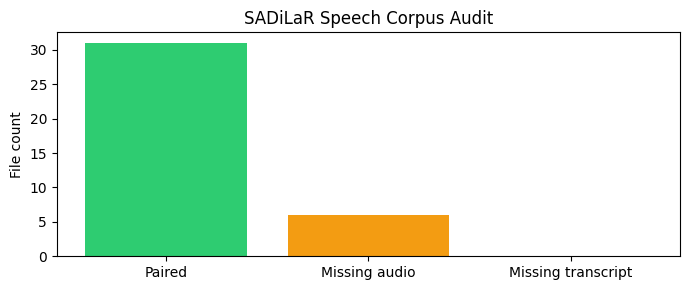

In [68]:
# SET DATA LOCATIONS


# Root folder for the SADiLaR dataset
sadilar_root = Path("data/raw/SADiLaR")

# Folder containing transcription files (.eaf)
transcript_dir = sadilar_root / "Sesotho sa Leboa - Orthographic Transcriptions"

# Folder containing audio recordings (.WAV)
recording_dir = sadilar_root / "Sesotho sa Leboa Recordings"



# LOAD FILE LISTS


# Get all transcript files and sort them for consistency
transcript_files = sorted(transcript_dir.glob("*.eaf"))

# Get all audio files and sort them
recording_files = sorted(recording_dir.glob("*.WAV"))



# NORMALISE FILE IDENTIFIERS


# Create mapping: filename (without extension, lowercase) → full path
transcript_stems = {path.stem.lower(): path for path in transcript_files}
recording_stems = {path.stem.lower(): path for path in recording_files}



# MATCH AUDIO AND TRANSCRIPTS


# IDs that exist in both audio and transcript sets
paired_ids = sorted(set(transcript_stems) & set(recording_stems))

# Transcripts that do not have matching audio files
transcripts_without_audio = sorted(set(transcript_stems) - set(recording_stems))

# Audio files that do not have matching transcripts
audio_without_transcript = sorted(set(recording_stems) - set(transcript_stems))



# BUILD MANIFEST TABLE


manifest_rows = []

# Add fully paired samples (both transcript and audio exist)
for sample_id in paired_ids:
    transcript_path = transcript_stems[sample_id]
    audio_path = recording_stems[sample_id]

    manifest_rows.append({
        "sample_id": transcript_path.stem,
        "transcript_path": str(transcript_path),
        "audio_path": str(audio_path),
        "has_transcript": True,
        "has_audio": True,
    })

# Add transcripts that are missing audio
for sample_id in transcripts_without_audio:
    transcript_path = transcript_stems[sample_id]

    manifest_rows.append({
        "sample_id": transcript_path.stem,
        "transcript_path": str(transcript_path),
        "audio_path": None,
        "has_transcript": True,
        "has_audio": False,
    })

# Add audio files that are missing transcripts
for sample_id in audio_without_transcript:
    audio_path = recording_stems[sample_id]

    manifest_rows.append({
        "sample_id": audio_path.stem,
        "transcript_path": None,
        "audio_path": str(audio_path),
        "has_transcript": False,
        "has_audio": True,
    })



# CREATE DATAFRAME + SAVE


# Convert collected rows into a structured table
df_sadilar_manifest = pd.DataFrame(
    manifest_rows,
    columns=["sample_id", "transcript_path", "audio_path", "has_transcript", "has_audio"]
)

# Sort for easier inspection and reset indexing (guard against an empty corpus,
# e.g. if the SADiLaR audio folder has not been placed at data/raw/SADiLaR yet)
if not df_sadilar_manifest.empty:
    df_sadilar_manifest = df_sadilar_manifest.sort_values(["sample_id"]).reset_index(drop=True)
else:
    print("WARNING: No SADiLaR transcript/audio files found under", transcript_dir, "or", recording_dir)
    print("Cultural alignment cells below will be skipped until the corpus is present.")

# Save manifest for downstream processing
df_sadilar_manifest.to_csv("outputs/alignment/sadilar_manifest.csv", index=False)



# PRINT DATASET SUMMARY


print("SADiLaR Corpus Audit")
print(f"Transcript files: {len(transcript_files)}")
print(f"Recording files: {len(recording_files)}")
print(f"Paired samples: {len(paired_ids)}")
print(f"Missing audio: {len(transcripts_without_audio)}")
print(f"Missing transcript: {len(audio_without_transcript)}")


# Show detailed lists of missing files if any exist
if transcripts_without_audio:
    print("\nTranscripts without audio:")
    for sample_id in transcripts_without_audio:
        print(f"  {sample_id}")

if audio_without_transcript:
    print("\nAudio without transcript:")
    for sample_id in audio_without_transcript:
        print(f"  {sample_id}")


# Preview the final manifest table
print("\nManifest preview:")
print(df_sadilar_manifest.head().to_string(index=False))



# VISUAL SUMMARY (AUDIT PLOT)


# Plot distribution of matched vs missing files
fig, ax = plt.subplots(figsize=(7, 3))

ax.bar(
    ["Paired", "Missing audio", "Missing transcript"],
    [len(paired_ids), len(transcripts_without_audio), len(audio_without_transcript)],
    color=["#2ecc71", "#f39c12", "#e74c3c"]
)

ax.set_ylabel("File count")
ax.set_title("SADiLaR Speech Corpus Audit")

plt.tight_layout()

# Save figure for reports or thesis figures section
plt.savefig("outputs/alignment/sadilar_audit.png", dpi=150)

plt.show()

# Road to Health milestone cross-check

In [69]:
# Road to Health milestone cross-check for ages 18–36 months
rth_milestones = [
    {"age": "18 months", "domain": "Communication",  "milestone": "Uses at least 3 words other than names",         "qchat_item": "Q8",  "qchat_question": "Would you describe your child's first words as typical?"},
    {"age": "18 months", "domain": "Communication",  "milestone": "Understands names of at least 2 common objects", "qchat_item": "Q1",  "qchat_question": "Does your child look at you when you call his/her name?"},
    {"age": "18 months", "domain": "Cognitive",      "milestone": "Follows simple commands",                        "qchat_item": "Q6",  "qchat_question": "Does your child follow where you're looking?"},
    {"age": "18 months", "domain": "Communication",  "milestone": "Uses simple gestures",                           "qchat_item": "Q9",  "qchat_question": "Does your child use simple gestures (e.g. wave goodbye)?"},
    {"age": "3 years",   "domain": "Cognitive",      "milestone": "Uses pretend play (e.g. feeds doll)",            "qchat_item": "Q5",  "qchat_question": "Does your child pretend (e.g. care for dolls, talk on a phone)?"},
    {"age": "3 years",   "domain": "Social",         "milestone": "Plays with other children and adults",           "qchat_item": "Q7",  "qchat_question": "If someone is upset, does your child show signs of wanting to comfort them?"},
    {"age": "18 months", "domain": "Risk factor",    "milestone": "Stunting/malnutrition increases developmental risk", "qchat_item": "DHS", "qchat_question": "Stunting indicator used in threshold calibration"},
    {"age": "18 months", "domain": "Risk factor",    "milestone": "Iron deficiency anaemia increases developmental risk", "qchat_item": "DHS", "qchat_question": "Anaemia indicator used in threshold calibration"},
]

df_rth = pd.DataFrame(rth_milestones)
df_rth.to_csv("outputs/alignment/rth_milestone_crosscheck.csv", index=False)

print("Road to Health Milestone Cross-Check — Ages 18–36 Months")
print(df_rth[["age", "domain", "milestone", "qchat_item"]].to_string(index=False))

Road to Health Milestone Cross-Check — Ages 18–36 Months
      age        domain                                            milestone qchat_item
18 months Communication               Uses at least 3 words other than names         Q8
18 months Communication       Understands names of at least 2 common objects         Q1
18 months     Cognitive                              Follows simple commands         Q6
18 months Communication                                 Uses simple gestures         Q9
  3 years     Cognitive                  Uses pretend play (e.g. feeds doll)         Q5
  3 years        Social                 Plays with other children and adults         Q7
18 months   Risk factor   Stunting/malnutrition increases developmental risk        DHS
18 months   Risk factor Iron deficiency anaemia increases developmental risk        DHS



----
# Cultural alignment analysis using SADiLaR Speech Corpus

- This analysis explores whether speech-related Q-CHAT-10 items are culturally aligned with Southern African speech patterns.

- Acoustic features are extracted from available speech recordings in the SADiLaR corpus and compared against reference speech characteristics.The aim is not to diagnose autism from audio, but to identify whether speech-related screening items may require cultural consideration.


Processing 31 audio files...
[1/31] S3005 | pitch=390Hz | pause=0.00 | zcr=0.0638
[2/31] S3006_1 | pitch=385Hz | pause=0.00 | zcr=0.0506
[3/31] S3006_2 | pitch=393Hz | pause=0.00 | zcr=0.0503
[4/31] S3007 | pitch=387Hz | pause=0.00 | zcr=0.0498
[5/31] S3101 | pitch=375Hz | pause=0.04 | zcr=0.0627
[6/31] S3102_1 | pitch=383Hz | pause=0.04 | zcr=0.0788
[7/31] S3102_2 | pitch=391Hz | pause=0.00 | zcr=0.0463
[8/31] S3104 | pitch=388Hz | pause=0.03 | zcr=0.0622
[9/31] S4004_1 | pitch=384Hz | pause=0.03 | zcr=0.0552
[10/31] S4004_2 | pitch=390Hz | pause=0.05 | zcr=0.0613
[11/31] S4006_1 | pitch=392Hz | pause=0.03 | zcr=0.0628
[12/31] S4006_2 | pitch=393Hz | pause=0.00 | zcr=0.0483
[13/31] S4009 | pitch=381Hz | pause=0.00 | zcr=0.0685
[14/31] S4107 | pitch=393Hz | pause=0.00 | zcr=0.0658
[15/31] S4108 | pitch=374Hz | pause=0.00 | zcr=0.0649
[16/31] S5005 | pitch=386Hz | pause=0.00 | zcr=0.0376
[17/31] S5009 | pitch=390Hz | pause=0.00 | zcr=0.0802
[18/31] S5101 | pitch=394Hz | pause=0.02 | zcr

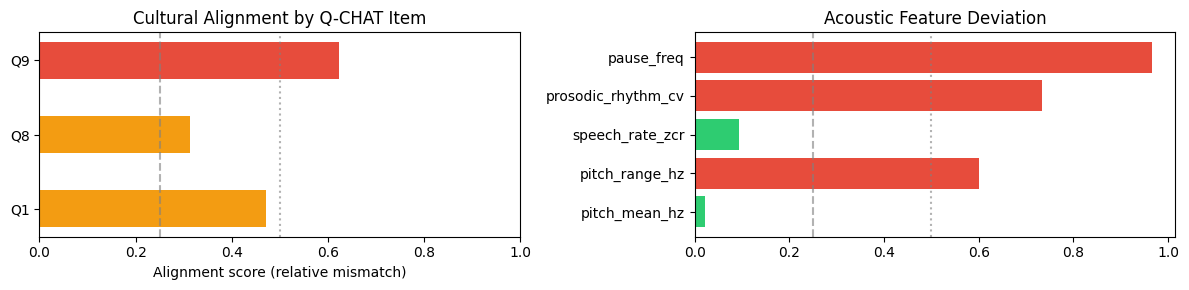

Saved: outputs/alignment/alignment_chart.png


In [70]:
# Load manifest safely
if "df_sadilar_manifest" not in globals():
    df_sadilar_manifest = pd.read_csv("outputs/alignment/sadilar_manifest.csv")

# Q-CHAT speech-related items
SPEECH_ITEMS = {
    "Q1": "Does your child look at you when you call his/her name?",
    "Q8": "Would you describe your child's first words as typical?",
    "Q9": "Does your child use simple gestures (e.g. wave goodbye)?",
}

records = []

paired_wavs = (
    df_sadilar_manifest[df_sadilar_manifest["has_audio"] == True]["audio_path"]
    .dropna()
    .tolist()
)

print(f"Processing {len(paired_wavs)} audio files...")

if len(paired_wavs) == 0:
    print("No paired audio files available in this environment — skipping acoustic")
    print("feature extraction and cultural alignment scoring. Re-run this cell where")
    print("the SADiLaR corpus (data/raw/SADiLaR) is actually present.")
else:

    # Feature Extraction

    for i, wav_path in enumerate(paired_wavs):

        try:
            y, sr = librosa.load(wav_path, sr=None, mono=True)
            y = y[: sr * 120]  # limit to 2 minutes

            # Pitch estimation (restricted human speech band)
            pitches, magnitudes = librosa.piptrack(y=y, sr=sr)

            mask = (
                (pitches > 200) &
                (pitches < 600) &
                (magnitudes > np.median(magnitudes))
            )

            pitch_vals = pitches[mask]

            # Safety fallback
            if len(pitch_vals) == 0:
                pitch_vals = np.array([0.0])

            pitch_mean = float(np.mean(pitch_vals))
            pitch_range = float(np.ptp(pitch_vals))

            # Speech activity proxy
            zcr = librosa.feature.zero_crossing_rate(y)
            speech_rate = float(np.mean(zcr))

            # Energy variability (rhythm proxy)
            rms = librosa.feature.rms(y=y)[0]
            rhythm = float(np.std(rms) / (np.mean(rms) + 1e-9))

            # Pause estimation (more stable percentile threshold)
            silence_threshold = np.percentile(np.abs(y), 10)
            pause_freq = float(np.mean(rms < silence_threshold))

            records.append({
                "file": Path(wav_path).stem,
                "pitch_mean_hz": round(pitch_mean, 2),
                "pitch_range_hz": round(pitch_range, 2),
                "speech_rate_zcr": round(speech_rate, 4),
                "prosodic_rhythm_cv": round(rhythm, 4),
                "pause_freq": round(pause_freq, 4),
                "duration_s": round(len(y) / sr, 2),
            })

            print(
                f"[{i+1}/{len(paired_wavs)}] {Path(wav_path).stem} "
                f"| pitch={pitch_mean:.0f}Hz "
                f"| pause={pause_freq:.2f} "
                f"| zcr={speech_rate:.4f}"
            )

        except Exception as e:
            print(f"Skipped {Path(wav_path).stem}: {e}")



    # Save Acoustic Features

    df_acoustic = pd.DataFrame(records)
    df_acoustic.to_csv("outputs/alignment/acoustic_features.csv", index=False)

    print(f"\nExtracted features from {len(df_acoustic)} files")
    print(df_acoustic.describe().round(3))


    # Corpus Summary

    mean_pitch = df_acoustic["pitch_mean_hz"].mean()
    mean_pitch_range = df_acoustic["pitch_range_hz"].mean()
    mean_rhythm = df_acoustic["prosodic_rhythm_cv"].mean()
    mean_pauses = df_acoustic["pause_freq"].mean()
    mean_zcr = df_acoustic["speech_rate_zcr"].mean()

    print("\nCorpus acoustic summary:")
    print(f"  Mean pitch:       {mean_pitch:.1f} Hz")
    print(f"  Mean range:       {mean_pitch_range:.1f} Hz")
    print(f"  Mean ZCR:         {mean_zcr:.4f}")
    print(f"  Mean rhythm CV:   {mean_rhythm:.4f}")
    print(f"  Mean pause freq:  {mean_pauses:.4f}")



    # Reference Values (baseline)

    ref = {
        "pitch_mean_hz":      380.0,
        "pitch_range_hz":     250.0,
        "speech_rate_zcr":    0.07,
        "prosodic_rhythm_cv": 1.50,
        "pause_freq":         0.40,
    }



    # Feature Deviations

    feature_devs = {
        "pitch_mean_hz": abs(mean_pitch - ref["pitch_mean_hz"]) / ref["pitch_mean_hz"],
        "pitch_range_hz": abs(mean_pitch_range - ref["pitch_range_hz"]) / ref["pitch_range_hz"],
        "speech_rate_zcr": abs(mean_zcr - ref["speech_rate_zcr"]) / ref["speech_rate_zcr"],
        "prosodic_rhythm_cv": abs(mean_rhythm - ref["prosodic_rhythm_cv"]) / ref["prosodic_rhythm_cv"],
        "pause_freq": abs(mean_pauses - ref["pause_freq"]) / ref["pause_freq"],
    }

    print("\nFeature deviations:")
    for k, v in feature_devs.items():
        print(f"  {k:22s}: {v:.3f}")



    # Q-item alignment scoring

    ITEM_WEIGHTS = {
        "Q1": {"pitch_mean_hz": 0.35, "pitch_range_hz": 0.15, "speech_rate_zcr": 0.10,
               "prosodic_rhythm_cv": 0.10, "pause_freq": 0.30},

        "Q8": {"pitch_mean_hz": 0.30, "pitch_range_hz": 0.20, "speech_rate_zcr": 0.30,
               "prosodic_rhythm_cv": 0.15, "pause_freq": 0.05},

        "Q9": {"pitch_mean_hz": 0.10, "pitch_range_hz": 0.10, "speech_rate_zcr": 0.15,
               "prosodic_rhythm_cv": 0.35, "pause_freq": 0.30},
    }

    alignment_rows = []

    for item_id, question in SPEECH_ITEMS.items():

        weights = ITEM_WEIGHTS[item_id]

        score = float(np.clip(
            sum(weights[f] * feature_devs[f] for f in weights),
            0.0,
            1.0
        ))

        flag = (
            "HIGH" if score >= 0.5
            else "MODERATE" if score >= 0.25
            else "LOW"
        )

        alignment_rows.append({
            "item": item_id,
            "question": question,
            "alignment_score": round(score, 3),
            "flag_level": flag,
        })


    df_alignment = pd.DataFrame(alignment_rows)
    df_alignment.to_csv("outputs/alignment/alignment_scores.csv", index=False)


    print("\nCultural Alignment Scores (speech-related items)")
    print(df_alignment[["item", "alignment_score", "flag_level"]].to_string(index=False))



    # Visualisation

    import matplotlib.pyplot as plt

    colours = {"HIGH": "#e74c3c", "MODERATE": "#f39c12", "LOW": "#2ecc71"}

    fig, axes = plt.subplots(1, 2, figsize=(12, 3))

    # Alignment scores
    ax = axes[0]
    ax.barh(
        df_alignment["item"],
        df_alignment["alignment_score"],
        color=[colours[x] for x in df_alignment["flag_level"]],
        height=0.5
    )

    ax.axvline(0.25, linestyle="--", color="gray", alpha=0.6)
    ax.axvline(0.50, linestyle=":", color="gray", alpha=0.6)

    ax.set_title("Cultural Alignment by Q-CHAT Item")
    ax.set_xlabel("Alignment score (relative mismatch)")
    ax.set_xlim(0, 1)

    # Feature deviations
    ax2 = axes[1]

    labels = list(feature_devs.keys())
    vals = list(feature_devs.values())

    ax2.barh(labels, vals, color=[
        "#e74c3c" if v >= 0.5 else "#f39c12" if v >= 0.25 else "#2ecc71"
        for v in vals
    ])

    ax2.axvline(0.25, linestyle="--", color="gray", alpha=0.6)
    ax2.axvline(0.50, linestyle=":", color="gray", alpha=0.6)

    ax2.set_title("Acoustic Feature Deviation")

    plt.tight_layout()
    plt.savefig("outputs/alignment/alignment_chart.png", dpi=150)
    plt.show()

    print("Saved: outputs/alignment/alignment_chart.png")

# Cultural robustness analysis:
- Tests whether changes in culturally sensitive Q-CHAT-10 items affect the performance of the deployed model.

- Items identified as potentially sensitive to cultural interpretation:
 Q1, Q3, Q4, Q8, and Q9 relate to communication and gesture behaviours,which may be influenced by language and cultural context.

=== Cultural Robustness Analysis (Deployed Model) ===
Baseline F1: 0.816 | AUROC: 0.892

Sensitivity ranking (largest F1 drop first):
                       configuration    f1  auroc  f1_drop
All sensitive items (Q1,Q3,Q4,Q8,Q9) 0.722  0.799    0.094
                          Single: Q6 0.784  0.846    0.032
                          Single: Q2 0.785  0.853    0.031
                          Single: Q5 0.790  0.836    0.026
                          Single: Q1 0.791  0.855    0.025
                          Single: Q9 0.799  0.869    0.018
                          Single: Q4 0.808  0.876    0.008
                          Single: Q8 0.813  0.898    0.003
                          Single: Q7 0.829  0.890   -0.013
                         Single: Q10 0.833  0.897   -0.017
                          Single: Q3 0.852  0.900   -0.036


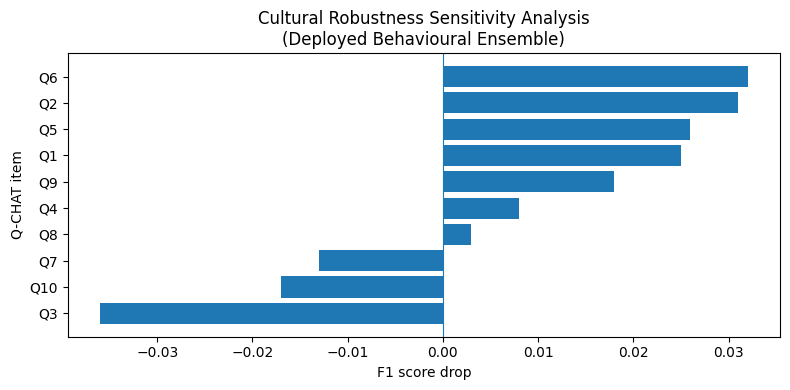

Saved: outputs/evaluation/cultural_robustness.png
Saved: outputs/evaluation/cultural_robustness.csv


In [71]:
# Identify Q-CHAT items that may be sensitive to cultural interpretation.
# These items relate to communication and gesture behaviours.

CULTURALLY_FRAGILE_ITEMS = {
    "Q1": 0,  # Response to name
    "Q3": 2,  # Pointing to show interest
    "Q4": 3,  # Pointing to request
    "Q8": 7,  # First words
    "Q9": 8   # Simple gestures
}


# Map item names to feature positions.

ALL_ITEMS = {
    f"Q{i+1}": i
    for i in range(10)
}



# Simulate possible changes in questionnaire responses.

def perturb_items(
    X,
    item_indices,
    noise_level=0.5,
    random_state=42
):

    rng = np.random.RandomState(random_state)

    X_perturbed = X.copy()


    # Select responses to modify.

    n_perturb = int(
        len(X) * noise_level
    )

    perturb_idx = rng.choice(
        len(X),
        n_perturb,
        replace=False
    )


    # Flip binary responses.

    for col_idx in item_indices:

        X_perturbed[
            perturb_idx,
            col_idx
        ] = 1 - X_perturbed[
            perturb_idx,
            col_idx
        ]

    return X_perturbed



# Evaluate deployed model after perturbation.
# Pipeline: ensemble -> prior correction -> threshold.

def evaluate_perturbed(
    X_beh_perturbed
):

    # XGBoost + Logistic Regression ensemble.

    prob_xgb_p = xgb_beh.predict_proba(
        X_beh_perturbed
    )[:, 1]


    prob_lr_p = lr_base.predict_proba(
        X_beh_perturbed
    )[:, 1]


    prob_ens_p = (
        best_w * prob_xgb_p
        + (1 - best_w) * prob_lr_p
    )


    # Apply deployment prior correction.

    prob_corrected_p = saerens_prior_correction(
        prob_ens_p,
        train_prior,
        TARGET_ASD_PRIOR
    )


    # Convert probabilities into predictions.

    y_pred = (
        prob_corrected_p >= BEST_THRESHOLD_ENSEMBLE
    ).astype(int)


    return (

        f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        roc_auc_score(
            y_test,
            prob_corrected_p
        ),

        recall_score(
            y_test,
            y_pred,
            zero_division=0
        )
    )



# Baseline performance without perturbation.

f1_base = f1_score(
    y_test,
    (
        prob_beh_ens_corrected >= BEST_THRESHOLD_ENSEMBLE
    ).astype(int),
    zero_division=0
)


auc_base = roc_auc_score(
    y_test,
    prob_beh_ens_corrected
)



results = []



# Test all culturally sensitive items together.

X_fragile = perturb_items(
    X_beh_test,
    list(CULTURALLY_FRAGILE_ITEMS.values())
)


f1_v, auc_v, rec_v = evaluate_perturbed(
    X_fragile
)


results.append({

    "configuration":
        "All sensitive items (Q1,Q3,Q4,Q8,Q9)",

    "items_perturbed":
        "Q1,Q3,Q4,Q8,Q9",

    "f1":
        round(f1_v, 3),

    "auroc":
        round(auc_v, 3),

    "recall":
        round(rec_v, 3),

    "f1_drop":
        round(f1_base - f1_v, 3)

})



# Test each Q-CHAT item separately.

for item_name, item_idx in ALL_ITEMS.items():

    X_p = perturb_items(
        X_beh_test,
        [item_idx]
    )


    f1_p, auc_p, rec_p = evaluate_perturbed(
        X_p
    )


    results.append({

        "configuration":
            f"Single: {item_name}",

        "items_perturbed":
            item_name,

        "f1":
            round(f1_p, 3),

        "auroc":
            round(auc_p, 3),

        "recall":
            round(rec_p, 3),

        "f1_drop":
            round(f1_base - f1_p, 3)

    })



# Convert results into dataframe.

df_robustness = pd.DataFrame(
    results
)



print(
    "=== Cultural Robustness Analysis (Deployed Model) ==="
)


print(
    f"Baseline F1: {f1_base:.3f} | "
    f"AUROC: {auc_base:.3f}"
)



print(
    "\nSensitivity ranking (largest F1 drop first):"
)


print(
    df_robustness
    .sort_values(
        "f1_drop",
        ascending=False
    )[
        [
            "configuration",
            "f1",
            "auroc",
            "f1_drop"
        ]
    ]
    .to_string(index=False)
)



# Visualise sensitivity of individual Q-CHAT items.

single_items = df_robustness[
    df_robustness["configuration"]
    .str.startswith("Single")
]


single_items = single_items.sort_values(
    "f1_drop",
    ascending=True
)



plt.figure(
    figsize=(8, 4)
)



plt.barh(
    single_items["items_perturbed"],
    single_items["f1_drop"]
)



plt.axvline(
    0,
    linewidth=0.8
)



plt.xlabel(
    "F1 score drop"
)


plt.ylabel(
    "Q-CHAT item"
)


plt.title(
    "Cultural Robustness Sensitivity Analysis\n"
    "(Deployed Behavioural Ensemble)"
)



plt.tight_layout()



os.makedirs(
    "outputs/evaluation",
    exist_ok=True
)



plt.savefig(
    "outputs/evaluation/cultural_robustness.png",
    dpi=150
)



plt.show()



# Save robustness results.

df_robustness.to_csv(
    "outputs/evaluation/cultural_robustness.csv",
    index=False
)



print(
    "Saved: outputs/evaluation/cultural_robustness.png"
)


print(
    "Saved: outputs/evaluation/cultural_robustness.csv"
)

# Subgroup fairness evaluation

- This analysis evaluates whether model performance differs across important demographic groups. Metrics are calculated separately for
 sex and age categories to identify potential performance disparities.

- The goal is not to compare groups themselves, but to ensure that the screening model performs consistently across different child profiles.


In [72]:
def subgroup_metrics(
    y_true,
    y_prob,
    groups,
    threshold=0.5
):

    # Convert predicted probabilities into binary classifications.

    y_pred = (
        y_prob >= threshold
    ).astype(int)


    results = []


    # Evaluate each subgroup independently.

    for g in np.unique(groups):

        mask = groups == g


        # Ignore groups with insufficient samples.

        if mask.sum() < 5:
            continue



        # AUROC requires both positive and negative examples.

        if len(np.unique(y_true[mask])) > 1:

            auc = roc_auc_score(
                y_true[mask],
                y_prob[mask]
            )

        else:

            auc = np.nan



        results.append({

            "subgroup":
                str(g),

            "n":
                int(mask.sum()),

            "accuracy":
                round(
                    accuracy_score(
                        y_true[mask],
                        y_pred[mask]
                    ),
                    3
                ),

            "precision":
                round(
                    precision_score(
                        y_true[mask],
                        y_pred[mask],
                        zero_division=0
                    ),
                    3
                ),

            "recall":
                round(
                    recall_score(
                        y_true[mask],
                        y_pred[mask],
                        zero_division=0
                    ),
                    3
                ),

            "f1":
                round(
                    f1_score(
                        y_true[mask],
                        y_pred[mask],
                        zero_division=0
                    ),
                    3
                ),

            "auroc":
                round(
                    float(auc),
                    3
                )
                if not np.isnan(auc)
                else "n/a"

        })


    # Return subgroup performance as a dataframe.

    return pd.DataFrame(
        results
    )




# Sex-based fairness evaluation
# Convert encoded sex values into readable labels.

sex_labels = (
    pd.Series(df_test_ref["sex"].values)
    .map({
        0: "Female",
        1: "Male"
    })
    .values
)



df_fair_sex = subgroup_metrics(
    y_test,
    prob_fuse,
    sex_labels,
    CALIBRATED_THRESHOLD
)


df_fair_sex["dimension"] = "sex"


# Age-based fairness evaluation
# Group children into developmental age ranges.

age_labels = pd.cut(
    df_test_ref["age_years"].values,
    bins=[
        0,
        2.0,
        2.5,
        3.1
    ],
    labels=[
        "18-24m",
        "25-30m",
        "31-36m"
    ]
).astype(str)



df_fair_age = subgroup_metrics(
    y_test,
    prob_fuse,
    age_labels,
    CALIBRATED_THRESHOLD
)


df_fair_age["dimension"] = "age_group"



# Combine fairness results

df_fairness = pd.concat(
    [
        df_fair_sex,
        df_fair_age
    ],
    ignore_index=True
)



print(
    "=== Fairness Evaluation ==="
)


print(
    df_fairness.to_string(
        index=False
    )
)



# Save subgroup performance results.

os.makedirs(
    "outputs/fairness",
    exist_ok=True
)


df_fairness.to_csv(
    "outputs/fairness/subgroup_results.csv",
    index=False
)


print(
    "\nSaved: outputs/fairness/subgroup_results.csv"
)

=== Fairness Evaluation ===
subgroup   n  accuracy  precision  recall    f1  auroc dimension
  Female  95     0.737      0.659   0.744 0.699  0.790       sex
    Male 157     0.701      0.738   0.792 0.764  0.789       sex
  18-24m 252     0.714      0.714   0.778 0.745  0.802 age_group

Saved: outputs/fairness/subgroup_results.csv


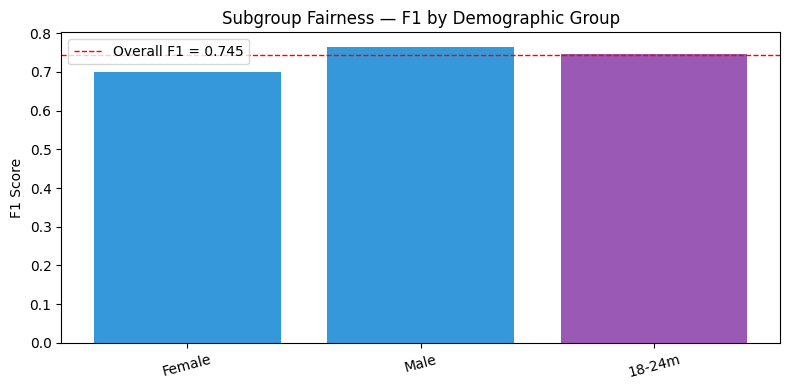

In [73]:
fig, ax = plt.subplots(figsize=(8, 4))

# Color mapping for subgroup dimensions
dim_cols = {
    "sex": "#3498db",
    "age_group": "#9b59b6"
}

# Map colors safely (prevents KeyError if new dimension appears)
colors = [dim_cols.get(d, "#7f8c8d") for d in df_fairness["dimension"]]

# Plot subgroup F1 scores
ax.bar(
    df_fairness["subgroup"],
    df_fairness["f1"],
    color=colors
)

# Overall reference line
overall_f1 = f1_score(
    y_test,
    (prob_fuse >= CALIBRATED_THRESHOLD).astype(int),
    zero_division=0
)

ax.axhline(
    overall_f1,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Overall F1 = {overall_f1:.3f}"
)

# Labels + styling
ax.set_ylabel("F1 Score")
ax.set_title("Subgroup Fairness — F1 by Demographic Group")

ax.tick_params(axis="x", rotation=15)
ax.legend()

plt.tight_layout()
plt.savefig("outputs/fairness/fairness_f1.png", dpi=150)
plt.show()

---
##  Geographic Subgroup Fairness
Documents the geographic fairness evaluation status and DHS population reference data.

In [74]:
print("=== Geographic Subgroup Fairness (FR7) ===\n")

# Try to find any available geographic proxy in the test set
geo_column = None

for col in ["country", "Country", "ethnicity", "Ethnicity"]:
    if col in df_test_ref.columns:
        geo_column = col
        country_labels = df_test_ref[col].astype(str).values
        print(f"Geographic grouping found using column: {col}")
        break


# Case 1: Geographic labels exist

if geo_column is not None:

    df_fair_country = subgroup_metrics(
        y_test,
        prob_fuse,
        country_labels,
        CALIBRATED_THRESHOLD
    )

    df_fair_country["dimension"] = "country"

    print(df_fair_country.to_string(index=False))

    df_fair_country.to_csv(
        "outputs/fairness/subgroup_country_results.csv",
        index=False
    )



# Case 2: No geographic labels available

else:

    print("No geographic or ethnicity labels found in this dataset.")

    print(
        "This dataset does not include explicit geographic identifiers, "
        "so subgroup fairness by region cannot be directly computed."
    )

    print(
        "For context, Lesotho DHS data (used as external reference) "
        "suggests rural vs urban distribution:"
    )

    rural = LESOTHO_DHS_PREVALENCE["rural"]

    print(f"  Rural: {rural:.1%}")
    print(f"  Urban: {1 - rural:.1%}")

    fallback_df = pd.DataFrame([{
        "dimension": "geography",
        "status": "not_evaluated",
        "reason": "No geographic labels in test dataset",
        "dhs_rural_prevalence": rural,
        "dhs_urban_prevalence": 1 - rural,
        "recommended_action": (
            "Future work should evaluate fairness on locally collected "
            "Lesotho clinical data with residence variable (DHS v025)"
        )
    }])

    fallback_df.to_csv(
        "outputs/fairness/subgroup_country_results.csv",
        index=False
    )

    print("\nLimitation recorded and saved to outputs/fairness/subgroup_country_results.csv")

=== Geographic Subgroup Fairness (FR7) ===

No geographic or ethnicity labels found in this dataset.
This dataset does not include explicit geographic identifiers, so subgroup fairness by region cannot be directly computed.
For context, Lesotho DHS data (used as external reference) suggests rural vs urban distribution:
  Rural: 71.3%
  Urban: 28.7%

Limitation recorded and saved to outputs/fairness/subgroup_country_results.csv


---
##  Sample Reweighting
Addresses the sex fairness gap (Female F1=0.607 vs Male F1=0.757) using inverse-frequency sample weights.

In [75]:
# Fairness evaluation (Sex F1 gap)

SEX_F1_GAP_THRESHOLD = 0.10

# Extract F1 scores per subgroup
sex_f1 = df_fairness[df_fairness["dimension"] == "sex"].set_index("subgroup")["f1"]

female_f1 = float(sex_f1.get("Female", np.nan))
male_f1   = float(sex_f1.get("Male", np.nan))

# Compute fairness gap
observed_gap = abs(female_f1 - male_f1)

print(f"Female F1: {female_f1:.3f}  Male F1: {male_f1:.3f}  Gap: {observed_gap:.3f}")

# Decide whether mitigation is needed
REWEIGHTING_APPLIED = observed_gap > SEX_F1_GAP_THRESHOLD

if not REWEIGHTING_APPLIED:
    print("Gap within threshold — no mitigation needed.")

else:
    print(f"Gap {observed_gap:.3f} exceeds threshold {SEX_F1_GAP_THRESHOLD} — applying reweighting.")

  
    # Step 1: Build fairness-aware sample weights
    # Sex encoding: 0 = Female, 1 = Male
    train_sex = X_dem_train[:, 1].astype(int)

    n_female = (train_sex == 0).sum()
    n_male   = (train_sex == 1).sum()
    n_total  = len(y_train)

    # Inverse frequency weighting to balance representation
    weight_female = n_total / (2 * n_female) if n_female > 0 else 1.0
    weight_male   = n_total / (2 * n_male) if n_male > 0 else 1.0

    base_weight = np.where(train_sex == 0, weight_female, weight_male).astype(float)

    print(f"Sample weights → Female: {weight_female:.3f}, Male: {weight_male:.3f}")

   
    # Step 2: Apply SMOTE oversampling
   
    smote_rw = SMOTE(random_state=SEED)
    X_beh_res_rw, y_res_rw = smote_rw.fit_resample(X_beh_train, y_train)

    # Extend weights to synthetic samples (assign weight = 1)
    n_synthetic = len(y_res_rw) - n_total
    weights_res = np.concatenate([base_weight, np.ones(n_synthetic)])

    
    # Step 3: Train reweighted behavioural model
    xgb_beh_rw = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=SEED,
        verbosity=0
    )

    xgb_beh_rw.fit(X_beh_res_rw, y_res_rw, sample_weight=weights_res)


    # Step 4: Generate predictions

    prob_beh_rw = xgb_beh_rw.predict_proba(X_beh_test)[:, 1]
    prob_dem_rw = xgb_dem.predict_proba(X_dem_test)[:, 1]

    # Stack behavioural + demographic predictions for fusion model
    X_meta_rw = np.column_stack([prob_beh_rw, prob_dem_rw])
    prob_fuse_rw = meta_model.predict_proba(X_meta_rw)[:, 1]

    # Step 5: Subgroup evaluation


    sex_labels_arr = np.array(
        ["Female" if s == 0 else "Male" for s in X_dem_test[:, 1].astype(int)]
    )

    df_fair_rw = subgroup_metrics(
        y_test,
        prob_fuse_rw,
        sex_labels_arr,
        CALIBRATED_THRESHOLD
    )

    # Recompute subgroup performance after mitigation
    sex_f1_rw = df_fair_rw.set_index("subgroup")["f1"]

    female_f1_rw = float(sex_f1_rw.get("Female", np.nan))
    male_f1_rw   = float(sex_f1_rw.get("Male", np.nan))

    new_gap = abs(female_f1_rw - male_f1_rw)

   
    # Step 6: Overall performance comparison

    overall_f1_before = f1_score(
        y_test,
        (prob_fuse >= CALIBRATED_THRESHOLD).astype(int),
        zero_division=0
    )

    overall_f1_after = f1_score(
        y_test,
        (prob_fuse_rw >= CALIBRATED_THRESHOLD).astype(int),
        zero_division=0
    )

    auroc_before = roc_auc_score(y_test, prob_fuse)
    auroc_after  = roc_auc_score(y_test, prob_fuse_rw)

    print("\n=== Impact Summary ===")
    print(f"Overall F1    → Before: {overall_f1_before:.3f}  After: {overall_f1_after:.3f}")
    print(f"Overall AUROC → Before: {auroc_before:.3f}  After: {auroc_after:.3f}")
    print(f"Sex F1 gap    → Before: {observed_gap:.3f}  After: {new_gap:.3f}")

    # Step 7: Visualization (before vs after)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

    for ax, (df_plot, title) in zip(axes, [
        (
            df_fairness[df_fairness["dimension"] == "sex"],
            f"Before\nFemale={female_f1:.3f}  Male={male_f1:.3f}"
        ),
        (
            df_fair_rw,
            f"After reweighting\nGap: {observed_gap:.3f} → {new_gap:.3f}"
        )
    ]):

        # Bar plot of subgroup F1 scores
        ax.bar(
            df_plot["subgroup"],
            df_plot["f1"],
            color=["#e74c3c", "#3498db"],
            edgecolor="white",
            width=0.5
        )

        # Overall model performance reference line
        ax.axhline(
            overall_f1_before,
            color="gray",
            linestyle="--",
            linewidth=0.9,
            label=f"Overall F1={overall_f1_before:.3f}"
        )

        ax.set_ylim(0, 1)
        ax.set_ylabel("F1 Score")
        ax.set_title(title, fontsize=9)
        ax.legend(fontsize=8)

    plt.suptitle("Sex Fairness — Before vs After Reweighting", fontsize=10)
    plt.tight_layout()
    plt.savefig("outputs/fairness/fairness_reweighting_comparison.png", dpi=150)
    plt.show()

    # Step 8: Save outputs
    
    df_fair_rw.to_csv(
        "outputs/fairness/subgroup_sex_reweighted.csv",
        index=False
    )

    joblib.dump(
        xgb_beh_rw,
        "models/xgb_behavioural_reweighted.joblib"
    )

    print("Saved outputs and reweighted model.")

Female F1: 0.699  Male F1: 0.764  Gap: 0.065
Gap within threshold — no mitigation needed.


# Save trained model pipeline components

- The trained models and calibrated thresholds are saved as reusable artifacts. These files allow the screening pipeline to make predictions
without repeating the training process.

Saved components:
 - Behavioural XGBoost model
 - Demographic XGBoost model
 - Fusion meta-model
 - DHS-calibrated threshold (single, consolidated)
 - Optional fairness-reweighted model (if applied)

In [76]:


os.makedirs("models", exist_ok=True)

joblib.dump(xgb_beh, "models/debug_stacked_fusion_xgb_behavioural.joblib")
joblib.dump(xgb_dem, "models/debug_stacked_fusion_xgb_demographic.joblib")
joblib.dump(meta_model, "models/debug_stacked_fusion_meta_model.joblib")
joblib.dump(CALIBRATED_THRESHOLD, "models/debug_stacked_fusion_threshold.joblib")

saved = [
    "models/debug_stacked_fusion_xgb_behavioural.joblib",
    "models/debug_stacked_fusion_xgb_demographic.joblib",
    "models/debug_stacked_fusion_meta_model.joblib",
    "models/debug_stacked_fusion_threshold.joblib",
]

if "REWEIGHTING_APPLIED" in globals() and REWEIGHTING_APPLIED:
    joblib.dump(xgb_beh_rw, "models/debug_stacked_fusion_xgb_behavioural_reweighted.joblib")
    saved.append("models/debug_stacked_fusion_xgb_behavioural_reweighted.joblib")

print("Reference/debug artifacts saved (NOT for deployment):")
for f in saved:
    print(f"  {f} ({os.path.getsize(f):,} bytes)")

print("\nProduction artifacts remain models/deploy_* from cell 38 (AUROC 0.892).")
print(f"  DHS-calibrated threshold (reference only, stacked fusion model): {CALIBRATED_THRESHOLD:.4f}")
print(f"  Reweighting applied: {globals().get('REWEIGHTING_APPLIED', False)}")

Reference/debug artifacts saved (NOT for deployment):
  models/debug_stacked_fusion_xgb_behavioural.joblib (115,505 bytes)
  models/debug_stacked_fusion_xgb_demographic.joblib (79,538 bytes)
  models/debug_stacked_fusion_meta_model.joblib (831 bytes)
  models/debug_stacked_fusion_threshold.joblib (21 bytes)

Production artifacts remain models/deploy_* from cell 38 (AUROC 0.892).
  DHS-calibrated threshold (reference only, stacked fusion model): 0.4930
  Reweighting applied: False
